# Employee Attrition Prediction using Machine Learning

---

## Business Problem

Employee attrition is a major challenge for organizations as it leads to increased recruitment and training costs, reduced productivity, loss of experienced employees, and disruptions in business operations. Identifying employees who are likely to leave enables organizations to implement proactive retention strategies and improve workforce stability.

This project analyzes the IBM HR Analytics Employee Attrition dataset and applies machine learning techniques to predict whether an employee is likely to leave the organization. In addition to building predictive models, the project aims to identify the key factors influencing employee attrition and provide actionable insights for Human Resources (HR).

---

## Project Objective

The primary objective of this project is to develop and evaluate machine learning models that can accurately predict employee attrition using employee demographic, professional, and workplace-related information.

The project objectives are:

- Perform comprehensive exploratory data analysis (EDA).
- Assess and improve data quality through preprocessing.
- Identify the most influential factors affecting employee attrition.
- Build and compare multiple machine learning classification models.
- Evaluate model performance using appropriate evaluation metrics.
- Generate actionable business insights and HR recommendations.

---

## Machine Learning Problem

This project is a **Supervised Binary Classification** problem.

**Target Variable:**

- **Attrition**
  - Yes
  - No

The machine learning models will learn from historical employee records to predict whether an employee is likely to leave the organization.

---

## Expected Business Impact

The findings of this project can help Human Resources (HR) departments to:

- Identify employees who are at a higher risk of leaving.
- Develop targeted employee retention strategies.
- Reduce recruitment and onboarding costs.
- Improve employee satisfaction and engagement.
- Support data-driven workforce planning and decision-making.

## Dataset Overview

**Dataset Name:** IBM HR Analytics Employee Attrition & Performance

**Problem Type:** Binary Classification

**Target Variable:** Attrition

The dataset contains employee demographic information, job-related attributes, compensation details, work-life balance indicators, and performance-related features. The objective is to predict whether an employee is likely to leave the organization based on these characteristics.

The dataset will be analyzed to identify patterns associated with employee attrition and to develop predictive models that can assist HR departments in making informed employee retention decisions.

## Import Libraries

In this section, we import all the libraries required for data manipulation, visualization, machine learning, and model evaluation.

Using only the necessary libraries keeps the notebook clean, readable, and reproducible.

The imported libraries are categorized based on their functionality to improve code organization and maintainability.

In [1]:
# SECTION 1: LIBRARY IMPORTS & PROJECT CONFIGURATION

# Standard Library Imports
from pathlib import Path
import warnings

# Data Manipulation
import numpy as np
import pandas as pd


# Data Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# Machine Learning - Data Preprocessing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.utils.class_weight import compute_sample_weight

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import shap

# Project Configuration
warnings.filterwarnings("ignore")

PROJECT_NAME     = "Employee Attrition Prediction using Machine Learning"
NOTEBOOK_VERSION = "1.0"
RANDOM_STATE     = 42
TARGET_COLUMN    = "Attrition"
TEST_SIZE        = 0.20

np.random.seed(RANDOM_STATE)


# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


# Visualization Settings
sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)

plt.rcParams.update({
    "figure.figsize"    : (10, 6),
    "figure.dpi"        : 120,
    "figure.facecolor"  : "white",
    "axes.titlesize"    : 16,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 12,
    "axes.labelweight"  : "bold",
    "axes.titlepad"     : 15,
    "axes.labelpad"     : 8,
})


# Project Directories
BASE_DIR  = Path.cwd()
CHARTS_DIR = BASE_DIR / "charts"

CHARTS_DIR.mkdir(exist_ok=True)


# Environment Check
print(PROJECT_NAME)
print(f"Notebook Version  : {NOTEBOOK_VERSION}")
print(f"Pandas Version    : {pd.__version__}")
print(f"NumPy Version     : {np.__version__}")
print()
print("Project Configuration Complete")
print("Libraries Imported")
print("Visualization Configured")
print("Charts Directory Ready")
print("Environment Ready")


Employee Attrition Prediction using Machine Learning
Notebook Version  : 1.0
Pandas Version    : 3.0.3
NumPy Version     : 2.4.6

Project Configuration Complete
Libraries Imported
Visualization Configured
Charts Directory Ready
Environment Ready


# Load Dataset

## Overview

In this section, the IBM HR Analytics Employee Attrition dataset is loaded into a Pandas DataFrame.

Before performing any preprocessing or analysis, it is important to verify that the dataset has been loaded correctly. We also examine the dimensions of the dataset to understand its size.

Using a structured loading process improves code readability, reproducibility, and reduces the likelihood of file path errors.

In [2]:
# SECTION 2: DATA LOADING

# We load into df_raw first and never touch it again.
# All transformations happen on df = df_raw.copy().
# This means we can always reset without re-reading the file.

df_raw = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = df_raw.copy()

print(f"Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"Memory  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Dataset loaded successfully.
Rows    : 1,470
Columns : 35
Memory  : 1040.5 KB


In [3]:
# SECTION 2: FIRST LOOK AT THE DATA

# df.head(10) shows the first 10 rows.
# This tells us:
# - Whether columns loaded with the right names
# - Whether values look sensible
# - Whether there are obvious formatting issues

print(f"First 10 rows of the dataset:\n")
df.head(10)

First 10 rows of the dataset:



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [4]:
# SECTION 2: COLUMN SUMMARY

# We build a structured summary DataFrame instead of using df.info().

# WHY NOT df.info()?
# df.info() prints to stdout and cannot be filtered, sorted, or saved.
# A DataFrame can be queried — e.g. show only columns with nulls,
# or only object columns. This is how production EDA is written.

col_summary = pd.DataFrame({
    "dtype"       : df.dtypes,
    "non_null"    : df.notna().sum(),
    "null_count"  : df.isna().sum(),
    "unique_vals" : df.nunique(),
    "sample_val"  : df.iloc[0],
}).reset_index().rename(columns={"index": "column"})

print(f"Column Summary ({len(col_summary)} columns total)\n")
print(col_summary.to_string(index=False))

Column Summary (35 columns total)

                  column dtype  non_null  null_count  unique_vals      sample_val
                     Age int64      1470           0           43              41
               Attrition   str      1470           0            2             Yes
          BusinessTravel   str      1470           0            3   Travel_Rarely
               DailyRate int64      1470           0          886            1102
              Department   str      1470           0            3           Sales
        DistanceFromHome int64      1470           0           29               1
               Education int64      1470           0            5               2
          EducationField   str      1470           0            6   Life Sciences
           EmployeeCount int64      1470           0            1               1
          EmployeeNumber int64      1470           0         1470               1
 EnvironmentSatisfaction int64      1470           0           

In [5]:
# SECTION 2: COLUMN TYPE SEPARATION

# Separating columns by type now means every downstream step
# (EDA, encoding, scaling) can reference these lists directly
# instead of manually filtering each time.

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
print(f"{numeric_cols}\n")

print(f"Categorical columns ({len(categorical_cols)}):")
print(f"{categorical_cols}")

Numeric columns (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [6]:
# SECTION 2: DESCRIPTIVE STATISTICS

# df.describe() gives count, mean, std, min, quartiles, max
# for every numeric column.

# What to look for:
#   - Min/max values that seem impossible (e.g. negative age)
#   - Very high standard deviation (wide spread in the data)
#   - Columns where min == max (constant columns — useless for modeling)

print("Descriptive Statistics — Numeric Columns\n")
df.describe().T.style.background_gradient(cmap="Blues")

Descriptive Statistics — Numeric Columns



,count,mean,std,min,25%,50%,75%,max
Age,1470.000000,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1470.000000,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1470.000000,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1470.000000,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1470.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1470.000000,1024.865306,602.024335,1.000000,491.250000,1020.500000,1555.750000,2068.000000
EnvironmentSatisfaction,1470.000000,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1470.000000,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1470.000000,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1470.000000,2.063946,1.106940,1.000000,1.000000,2.000000,3.000000,5.000000


In [7]:
# SECTION 2: TARGET VARIABLE — ATTRITION
# This is the single most important check before any modeling.

# WHY IT MATTERS:
# If 83.9% stayed and 16.1% left, a model that always predicts "No"
# gets 83.9% accuracy — while being completely useless to HR.
# This is the class imbalance problem, and it changes:
#   - Which metrics we use (F1, ROC-AUC — not accuracy)
#   - How we train models (class_weight='balanced')
#   - How we split data (StratifiedKFold — not random)

counts = df[TARGET_COLUMN].value_counts()
pcts   = df[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(1)

print(f"TARGET VARIABLE: {TARGET_COLUMN}")

for label in counts.index:
    bar = "█" * int(pcts[label] / 2)
    print(f"  {label:<5} | {bar:<45} | {counts[label]:>4}  ({pcts[label]}%)")
    
print(f"\n  Imbalance ratio  : {counts['No'] / counts['Yes']:.1f} : 1  (No : Yes)")
print(f"Primary metrics  : F1-Score + ROC-AUC  (not accuracy)")
print(f"Model strategy   : class_weight='balanced' in all models")
print(f"Split strategy   : StratifiedKFold to preserve class ratio")

TARGET VARIABLE: Attrition
  No    | █████████████████████████████████████████     | 1233  (83.9%)
  Yes   | ████████                                      |  237  (16.1%)

  Imbalance ratio  : 5.2 : 1  (No : Yes)
Primary metrics  : F1-Score + ROC-AUC  (not accuracy)
Model strategy   : class_weight='balanced' in all models
Split strategy   : StratifiedKFold to preserve class ratio


## Section 2 Summary — Data Loading & Initial Exploration

| Item | Finding |
|---|---|
| Total Records | 1,470 |
| Total Features | 35 (26 numeric, 9 categorical) |
| Missing Values | None detected |
| Target Variable | `Attrition` — Yes (16.1%) / No (83.9%) |
| Class Imbalance | 5.2 : 1 ratio — requires balanced training strategy |

### Decisions Made in This Section

**Metric choice:** Accuracy is misleading on this dataset. All evaluation
will use F1-Score and ROC-AUC as primary metrics.

**Model strategy:** All classifiers will use `class_weight='balanced'`
to prevent the majority class from dominating predictions.

**Split strategy:** `train_test_split` with `stratify=y` ensures both
train and test sets preserve the 83.9% / 16.1% class ratio.

---

# Initial Data Exploration

## Overview

Before performing data preprocessing or building machine learning models, it is essential to understand the structure and characteristics of the dataset.

In this section, we will:

- Examine the dataset dimensions.
- Identify feature names and data types.
- Check for missing values.
- Review summary statistics.
- Understand the overall quality of the dataset.

This preliminary exploration helps identify potential data quality issues and guides the preprocessing steps required before model development.

In [8]:
# SECTION 3: MISSING VALUE CHECK

# WHY THIS MATTERS:
# Most ML models cannot handle NaN values and will either throw an error
# or silently produce wrong results. We check before assuming.

# The IBM HR dataset is known to be clean, but we verify this explicitly
# rather than assuming — because in a real project, assumptions about
# data quality are where silent bugs come from.

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)


print("MISSING VALUE REPORT")

if missing.empty:
    print("No missing values found in any column.")
    print(f"All {df.shape[1]} columns are 100% complete.")
else:
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({
        "missing_count"   : missing,
        "missing_percent" : missing_pct
    })
    print(missing_report.to_string())
    print(f"\n{len(missing)} column(s) have missing values.")
    print("These will need imputation or removal before modeling.")


MISSING VALUE REPORT
No missing values found in any column.
All 35 columns are 100% complete.


In [9]:
# SECTION 3: DUPLICATE ROW CHECK
# WHY THIS MATTERS:
# Duplicate rows cause data leakage between train and test sets.
# If the same employee appears in both splits, the model has effectively
# "seen" that employee during training — inflating evaluation metrics.

# In HR data specifically, each row should represent one unique employee.
# Two identical rows means either a data entry error or a pipeline bug.

duplicate_count = df.duplicated().sum()

print("DUPLICATE ROW REPORT")

if duplicate_count == 0:
    print(f"No duplicate rows found.")
    print(f"All {len(df):,} rows represent unique employees.")
else:
    print(f"{duplicate_count} duplicate row(s) found.")
    print(f"Dropping duplicates and resetting index.")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Remaining rows: {len(df):,}")



DUPLICATE ROW REPORT
No duplicate rows found.
All 1,470 rows represent unique employees.


In [10]:
# SECTION 3: CONSTANT COLUMN DETECTION

# A constant column has the same value in every single row.
# It carries zero information — a model cannot learn anything from it.
# Including it wastes compute and can confuse tree-based models.

# The IBM HR dataset has three known constant columns:
#   - EmployeeCount  : always 1
#   - StandardHours  : always 80
#   - Over18         : always 'Y'

# We detect these programmatically rather than hardcoding the names —
# this way the code still works if the dataset changes.

constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print("CONSTANT COLUMN REPORT")

if not constant_cols:
    print("No constant columns found.")
else:
    for col in constant_cols:
        print(f"'{col}' — only value: {df[col].unique()[0]!r}")
    print(f"\nThese {len(constant_cols)} column(s) will be dropped.")
    print("Reason: zero variance = zero predictive value.")


CONSTANT COLUMN REPORT
'EmployeeCount' — only value: np.int64(1)
'Over18' — only value: 'Y'
'StandardHours' — only value: np.int64(80)

These 3 column(s) will be dropped.
Reason: zero variance = zero predictive value.


In [11]:
# SECTION 3: IDENTIFIER COLUMN DETECTION

# An identifier column (like EmployeeNumber) has a unique value per row.
# Including it in a model would cause severe overfitting — the model
# would memorize employee IDs rather than learning real patterns.

# We detect these by finding columns where unique value count == row count.
# We exclude the target column from this check.


id_cols = [
    col for col in df.columns
    if df[col].nunique() == len(df) and col != TARGET_COLUMN
]

print("IDENTIFIER COLUMN REPORT")

if not id_cols:
    print("No identifier columns found.")
else:
    for col in id_cols:
        print(f"'{col}' — {df[col].nunique()} unique values across {len(df)} rows")
    print(f"\nThese {len(id_cols)} column(s) will be dropped.")
    print("Reason: unique per row = acts as an index, not a feature.")


IDENTIFIER COLUMN REPORT
'EmployeeNumber' — 1470 unique values across 1470 rows

These 1 column(s) will be dropped.
Reason: unique per row = acts as an index, not a feature.


# Data Cleaning

## Overview

Data cleaning is a critical step before model development.

During the initial exploration, several columns were identified that do not contribute meaningful information for prediction.

These include:

- Constant columns that contain the same value for every employee.
- Identifier columns that uniquely identify each employee but have no predictive value.

Removing these columns improves model performance, reduces unnecessary complexity, and prevents the model from learning irrelevant patterns.

In [12]:

# SECTION 4: REMOVE NON-INFORMATIVE FEATURES

# Constant columns identified during exploration
constant_columns = [
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

# Identifier columns
identifier_columns = [
    "EmployeeNumber"
]

# Combine columns to remove
columns_to_drop = constant_columns + identifier_columns

# Drop columns
df.drop(columns=columns_to_drop, inplace=True)

print("NON-INFORMATIVE FEATURES REMOVED")

print(f"Columns Removed : {len(columns_to_drop)}")

for column in columns_to_drop:
    print(f"✓ {column}")

print("\nUpdated Dataset Shape")
print(df.shape)

NON-INFORMATIVE FEATURES REMOVED
Columns Removed : 4
✓ EmployeeCount
✓ Over18
✓ StandardHours
✓ EmployeeNumber

Updated Dataset Shape
(1470, 31)


### Interpretation

Four columns were removed from the dataset because they do not provide useful information for predicting employee attrition.

- `EmployeeCount`, `Over18`, and `StandardHours` contain only a single value for all employees, resulting in zero variance.
- `EmployeeNumber` is a unique identifier and does not represent an employee characteristic.

Removing these features simplifies the dataset and ensures that the machine learning models focus on meaningful predictive variables.

# Data Quality Assessment

## Overview

Before performing exploratory data analysis or training machine learning models, it is essential to assess the quality of the dataset.

Poor data quality can negatively impact model performance and lead to incorrect business conclusions.

In this section, we evaluate:

- Missing values
- Duplicate records
- Data types
- Number of unique values
- Feature quality

This assessment ensures that the dataset is reliable and suitable for predictive modeling.

In [13]:
# SECTION 5: DATA QUALITY REPORT

# Create Data Quality Report
data_quality = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})

# Add Recommendation column
data_quality["Recommendation"] = np.where(
    data_quality["Missing Values"] > 0,
    "Check Missing Values",
    "No Action Required"
)

# Sort by missing values
data_quality = data_quality.sort_values(
    by="Missing Values",
    ascending=False
)

data_quality

,Data Type,Missing Values,Missing (%),Unique Values,Recommendation
Age,int64,0,0.00,43,No Action Required
Attrition,str,0,0.00,2,No Action Required
BusinessTravel,str,0,0.00,3,No Action Required
DailyRate,int64,0,0.00,886,No Action Required
Department,str,0,0.00,3,No Action Required
DistanceFromHome,int64,0,0.00,29,No Action Required
Education,int64,0,0.00,5,No Action Required
EducationField,str,0,0.00,6,No Action Required
EnvironmentSatisfaction,int64,0,0.00,4,No Action Required
Gender,str,0,0.00,2,No Action Required


### Interpretation

The Data Quality Report provides a comprehensive overview of every feature in the dataset.

For each feature, it summarizes:

- Data type
- Number of missing values
- Percentage of missing values
- Number of unique values
- Recommended action

This report helps identify potential preprocessing requirements before exploratory data analysis and model development.

In [14]:
# MISSING VALUE SUMMARY

missing_values = df.isnull().sum().sum()

print("MISSING VALUE REPORT")

if missing_values == 0:
    print("No missing values found in the dataset.")
else:
    print(f"Total Missing Values : {missing_values}")

MISSING VALUE REPORT
No missing values found in the dataset.


In [15]:
# DUPLICATE RECORD CHECK

duplicates = df.duplicated().sum()

print("DUPLICATE RECORD REPORT")

if duplicates == 0:
    print("No duplicate records found.")
else:
    print(f"Duplicate Records : {duplicates}")

DUPLICATE RECORD REPORT
No duplicate records found.


### Interpretation

The IBM HR Analytics dataset contains no missing values and no duplicate records.

This indicates that the dataset is well-structured and requires minimal cleaning before analysis.

As a result, the next phase of the project can focus on understanding employee behavior through exploratory data analysis rather than performing extensive data cleaning.

In [16]:
# FINAL DATASET SHAPE

print("FINAL DATASET SUMMARY")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

FINAL DATASET SUMMARY
Rows    : 1470
Columns : 31


# Exploratory Data Analysis (EDA)

## Overview

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the employee data, identify patterns, detect relationships between variables, and generate business insights.

The analysis is divided into the following sections:

1. Target Variable Analysis
2. Numerical Feature Analysis
3. Categorical Feature Analysis
4. Relationship with Employee Attrition
5. Correlation Analysis

The insights obtained from EDA will guide feature selection, preprocessing, and model development.

## 6.1 Target Variable Analysis

The first step in exploratory data analysis is to examine the distribution of the target variable.

Understanding the proportion of employees who stayed versus those who left the organization helps identify class imbalance and provides an overview of employee attrition within the company.

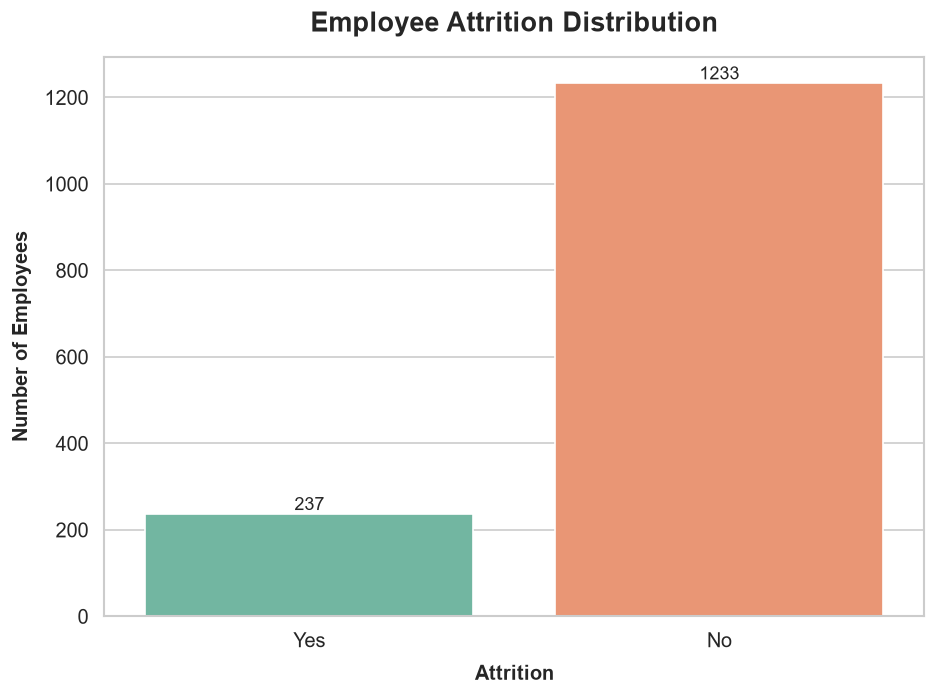

In [17]:
# SECTION 6.1: ATTRITION DISTRIBUTION

# Calculate employee attrition counts
attrition_counts = df[TARGET_COLUMN].value_counts()

# Create figure
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df,
    x=TARGET_COLUMN,
    palette="Set2"
)

# Add labels above each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.title("Employee Attrition Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.savefig(
    "charts/attrition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "charts/attrition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [18]:
# Calculate attrition percentage
attrition_percentage = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

attrition_percentage.to_frame(name="Percentage")

,Percentage
Attrition,
No,83.88
Yes,16.12


### Interpretation

The target variable distribution provides an overview of employee attrition within the organization.

A higher proportion of employees in the **"No"** category indicates that most employees remain with the company, while the **"Yes"** category represents employees who left the organization.

This distribution is important because it helps identify whether the dataset is balanced or imbalanced, which may influence model evaluation and the choice of performance metrics.

### Business Insight

The organization retains the majority of its employees, while a smaller proportion experiences attrition.

Although the number of employees leaving is comparatively lower, each resignation may result in recruitment costs, training expenses, productivity loss, and disruption to business operations.

Understanding the characteristics of employees who leave the organization will help HR departments design targeted retention strategies.

### HR Recommendation

Rather than applying retention strategies uniformly across all employees, HR teams should focus on identifying groups with a higher probability of attrition and implement targeted interventions based on data-driven insights.

## 6.2 Numerical Feature Analysis

Numerical features provide valuable insights into employee demographics, compensation, experience, and tenure.

Analyzing their distributions helps identify patterns, detect potential outliers, and understand how these variables may influence employee attrition.

The following numerical variables are explored:

- Age
- Monthly Income
- Total Working Years
- Years At Company
- Distance From Home

In [19]:
# HELPER FUNCTION: NUMERICAL FEATURE VISUALIZATION

def plot_numerical_feature(data, column, color="#4C72B0"):
    """
    Displays the distribution of a numerical feature.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset containing the feature.

    column : str
        Numerical feature to visualize.

    color : str
        Histogram color.
    """

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram
    sns.histplot(
        data[column],
        kde=True,
        color=color,
        ax=axes[0]
    )

    axes[0].set_title(f"{column} Distribution", fontsize=14, fontweight="bold")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")

    # Boxplot
    sns.boxplot(
        x=data[column],
        color=color,
        ax=axes[1]
    )

    axes[1].set_title(f"{column} Boxplot", fontsize=14, fontweight="bold")
    axes[1].set_xlabel(column)

    plt.tight_layout()
    plt.savefig(
    f"charts/{column.lower()}_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

### Age Distribution

Employee age is an important demographic factor that may influence employee retention.

Understanding the age distribution helps identify the dominant workforce age group and determine whether certain age ranges are more likely to experience attrition.

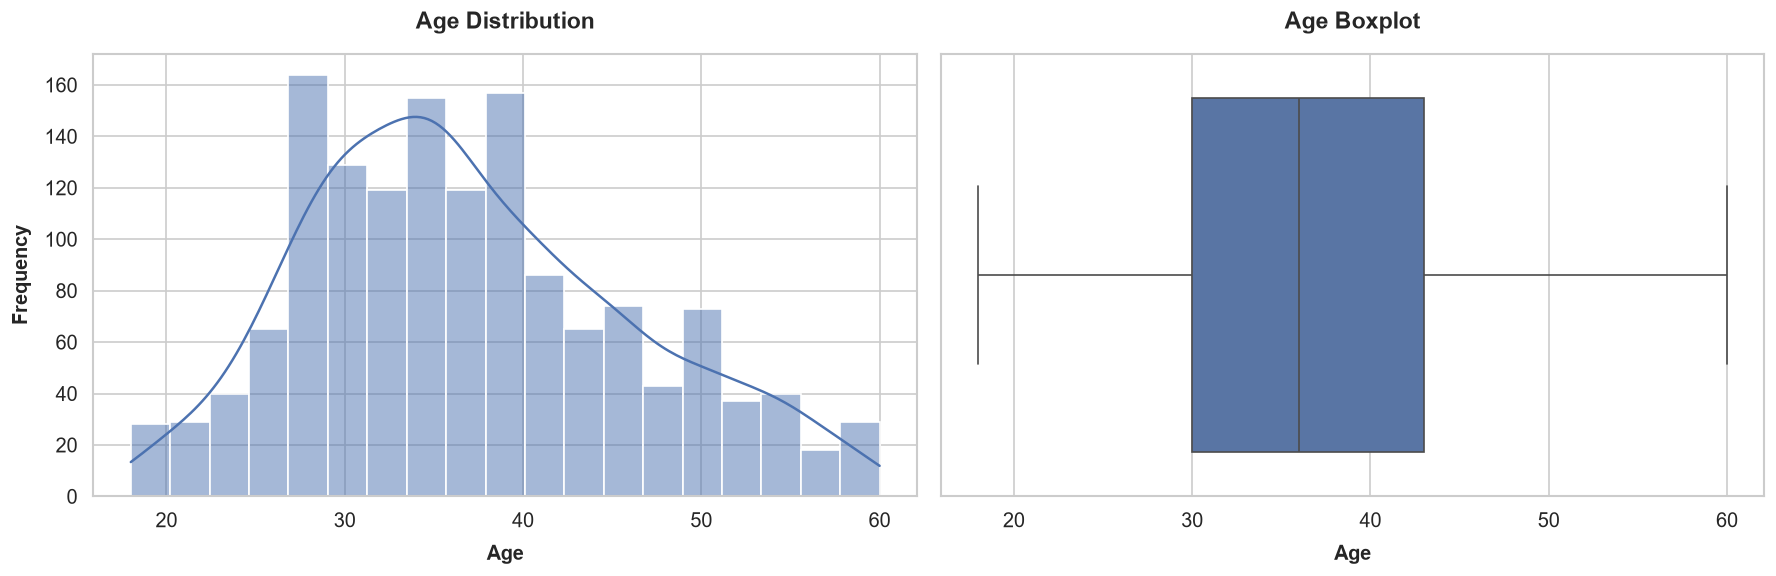

In [20]:
plot_numerical_feature(df, "Age")

In [21]:
df["Age"].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.00,36.92,9.14,18.00,30.00,36.00,43.00,60.00


### Interpretation

The histogram illustrates the distribution of employee ages, while the boxplot highlights the spread and potential outliers.

The statistical summary provides key descriptive measures, including the average age, median, minimum, maximum, and quartiles.

These insights help determine whether the workforce is concentrated within specific age groups or broadly distributed.

### Business Insight

Employee age often influences career priorities, job stability, and promotion expectations.

If younger employees exhibit higher attrition rates in later analyses, HR may consider enhancing career development opportunities, mentorship programs, and internal growth pathways.

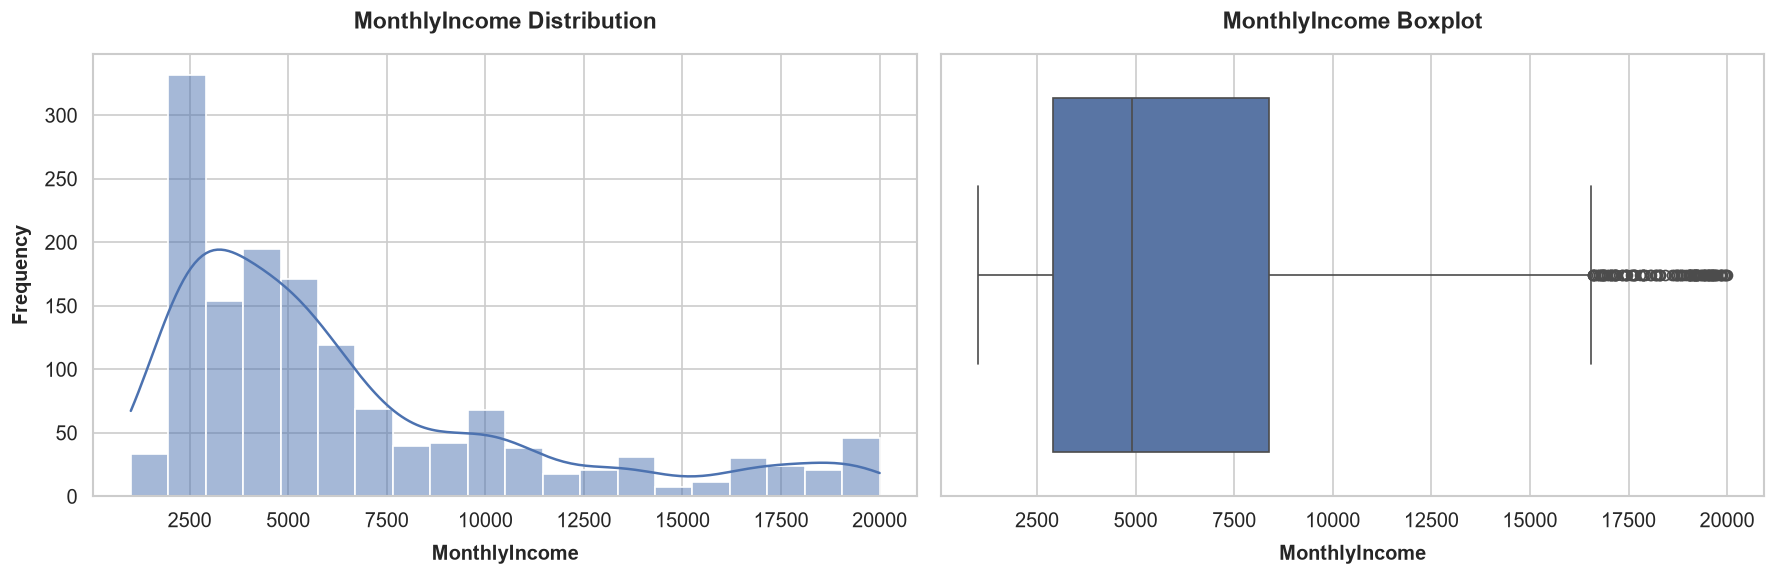

,count,mean,std,min,25%,50%,75%,max
MonthlyIncome,1470.00,6502.93,4707.96,1009.00,2911.00,4919.00,8379.00,19999.00


In [22]:
plot_numerical_feature(df, "MonthlyIncome")

df["MonthlyIncome"].describe().to_frame().T

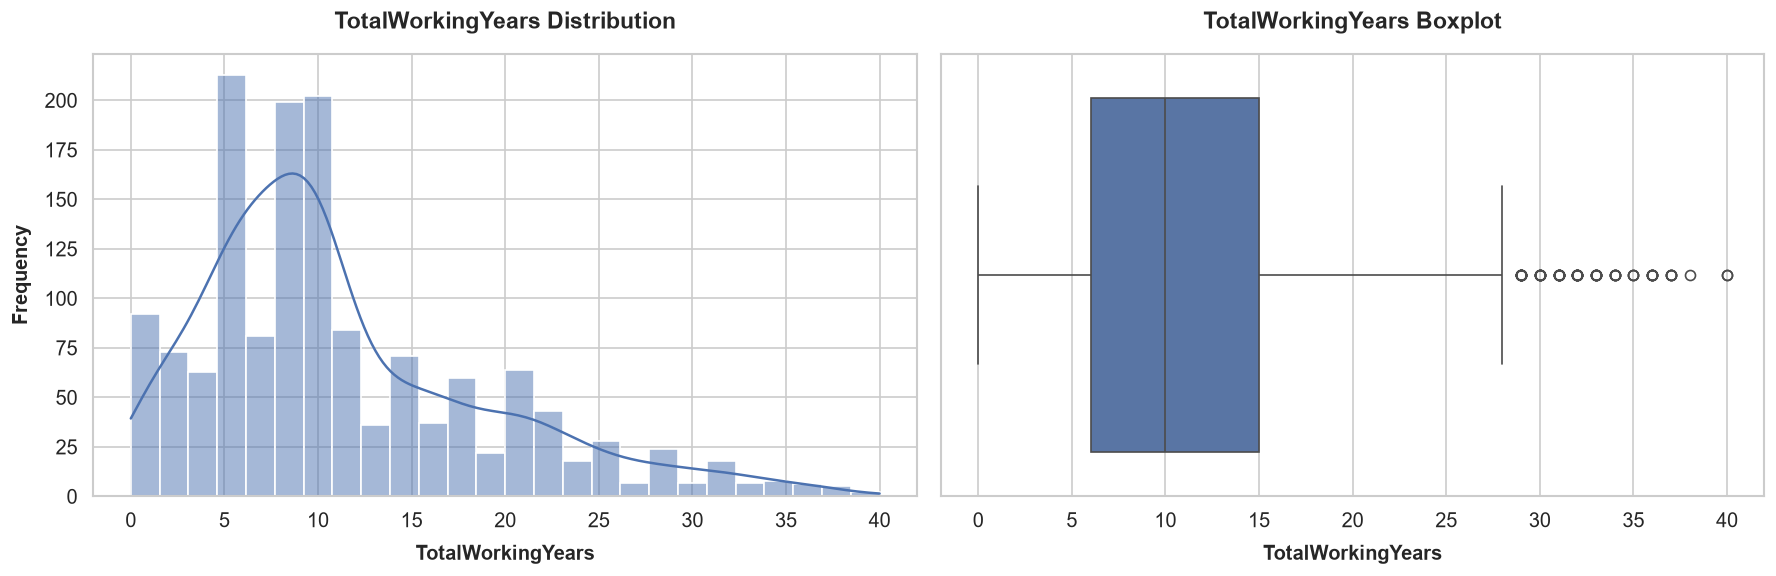

,count,mean,std,min,25%,50%,75%,max
TotalWorkingYears,1470.00,11.28,7.78,0.00,6.00,10.00,15.00,40.00


In [23]:
plot_numerical_feature(df, "TotalWorkingYears")

df["TotalWorkingYears"].describe().to_frame().T

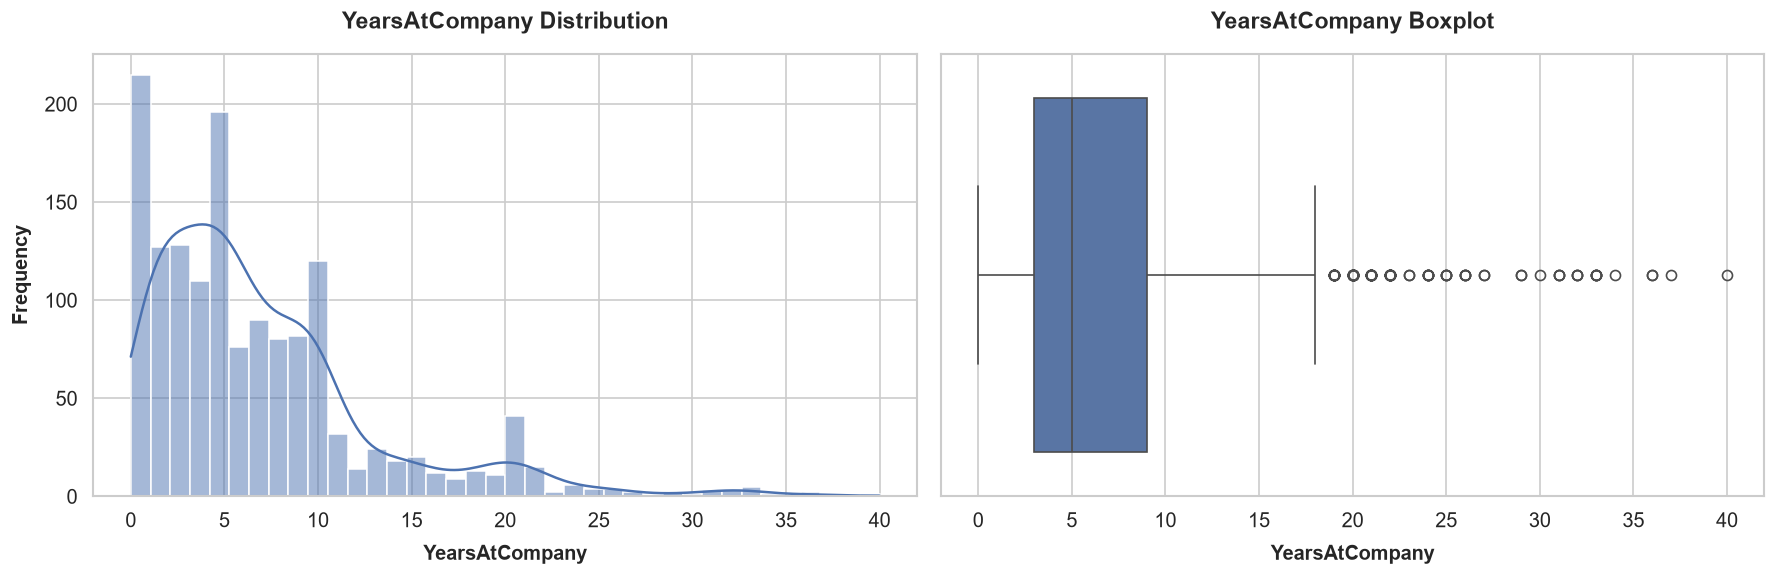

,count,mean,std,min,25%,50%,75%,max
YearsAtCompany,1470.00,7.01,6.13,0.00,3.00,5.00,9.00,40.00


In [24]:
plot_numerical_feature(df, "YearsAtCompany")

df["YearsAtCompany"].describe().to_frame().T

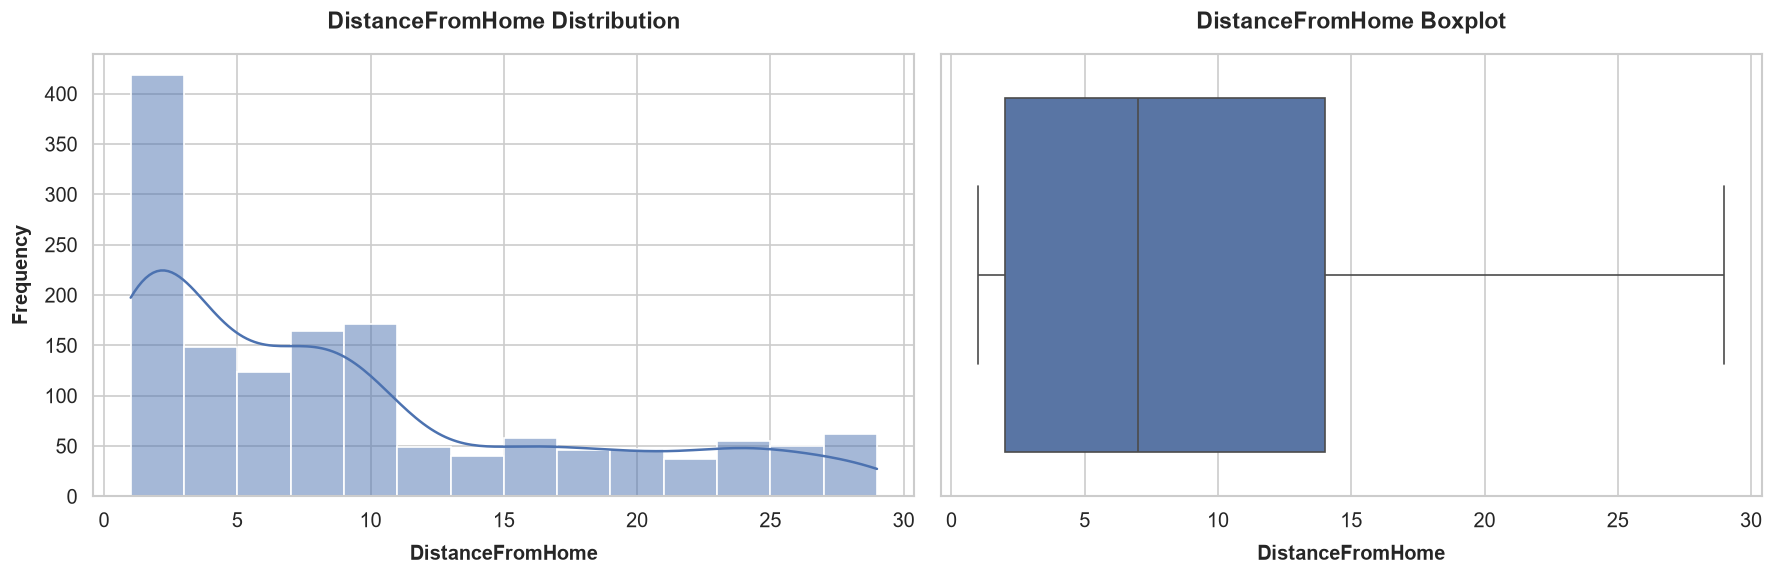

,count,mean,std,min,25%,50%,75%,max
DistanceFromHome,1470.00,9.19,8.11,1.00,2.00,7.00,14.00,29.00


In [25]:
plot_numerical_feature(df, "DistanceFromHome")

df["DistanceFromHome"].describe().to_frame().T

## 6.3 Categorical Feature Analysis

Categorical variables describe employee demographics, organizational structure, and workplace characteristics.

Analyzing these variables helps identify patterns within the workforce and understand how employees are distributed across different categories.

The following features are examined:

- Gender
- Department
- Job Role
- Business Travel
- Marital Status
- Education Field
- Overtime

In [26]:
# HELPER FUNCTION: CATEGORICAL FEATURE VISUALIZATION

def plot_categorical_feature(data, column, color="#4C72B0"):
    """
    Display the distribution of a categorical feature.

    Parameters:
    data : pandas.DataFrame
        Dataset containing the feature.

    column : str
        Categorical feature to visualize.

    color : str
        Color of the bars.
    """

    order = data[column].value_counts().index

    plt.figure(figsize=(10, 5))

    ax = sns.countplot(
        data=data,
        y=column,
        order=order,
        color=color
    )

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container)

    plt.title(
        f"{column} Distribution",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel("Number of Employees")
    plt.ylabel(column)

    plt.tight_layout()
    plt.savefig(
    f"charts/{column.lower()}_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

### Gender Distribution

This visualization shows the distribution of employees by gender.

Understanding workforce composition helps HR evaluate diversity and identify potential representation differences across the organization.

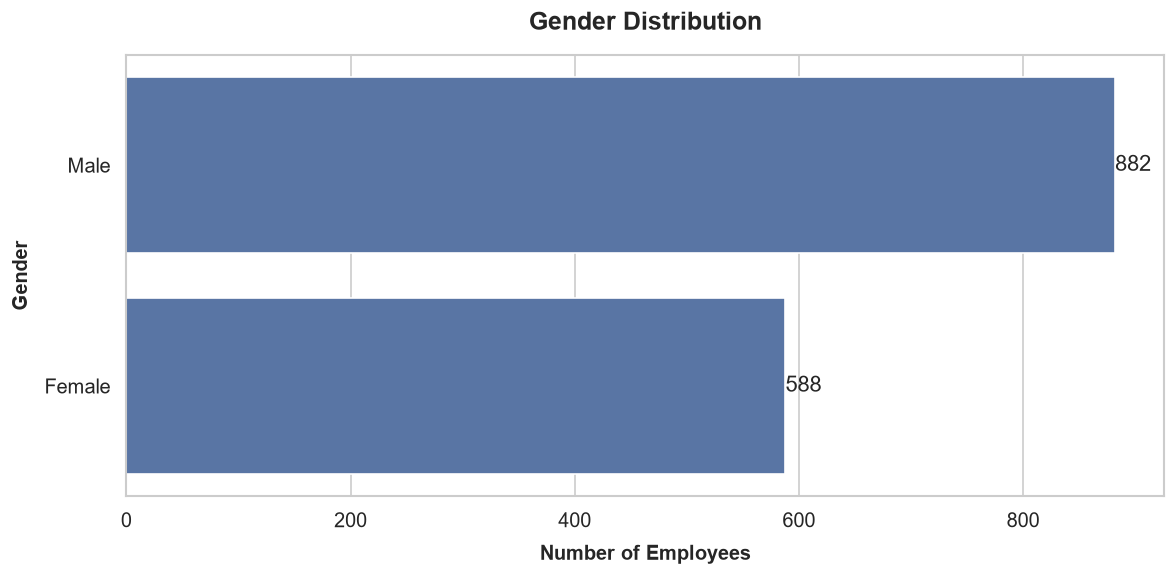

In [27]:
plot_categorical_feature(df, "Gender")

### Department Distribution

Departments represent the functional divisions of the organization.

Analyzing employee distribution across departments provides insight into workforce allocation and organizational structure.

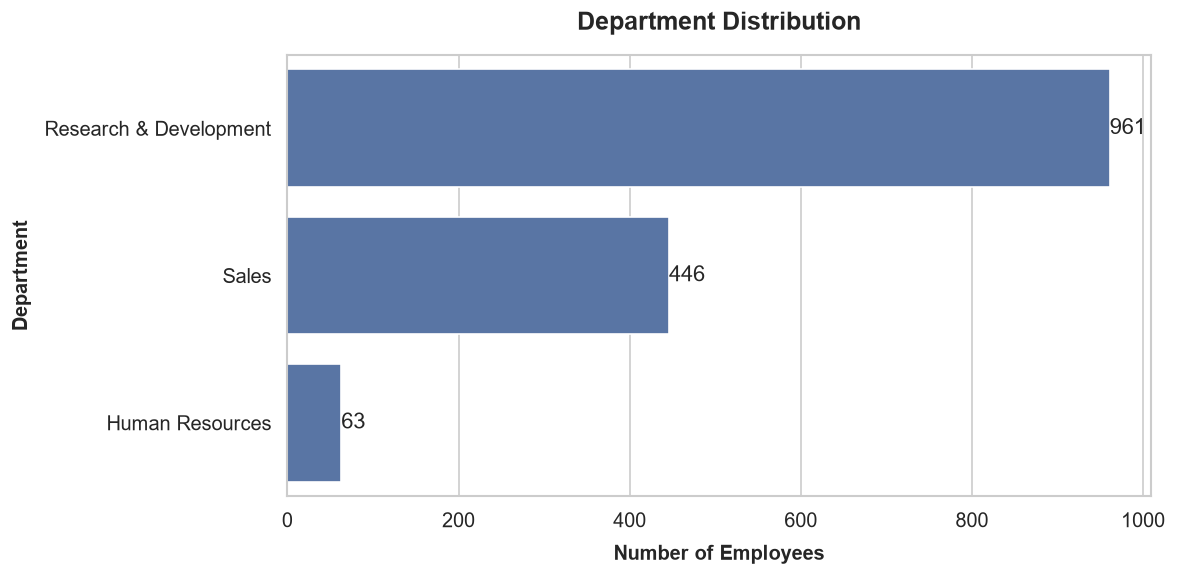

In [28]:
plot_categorical_feature(df, "Department")

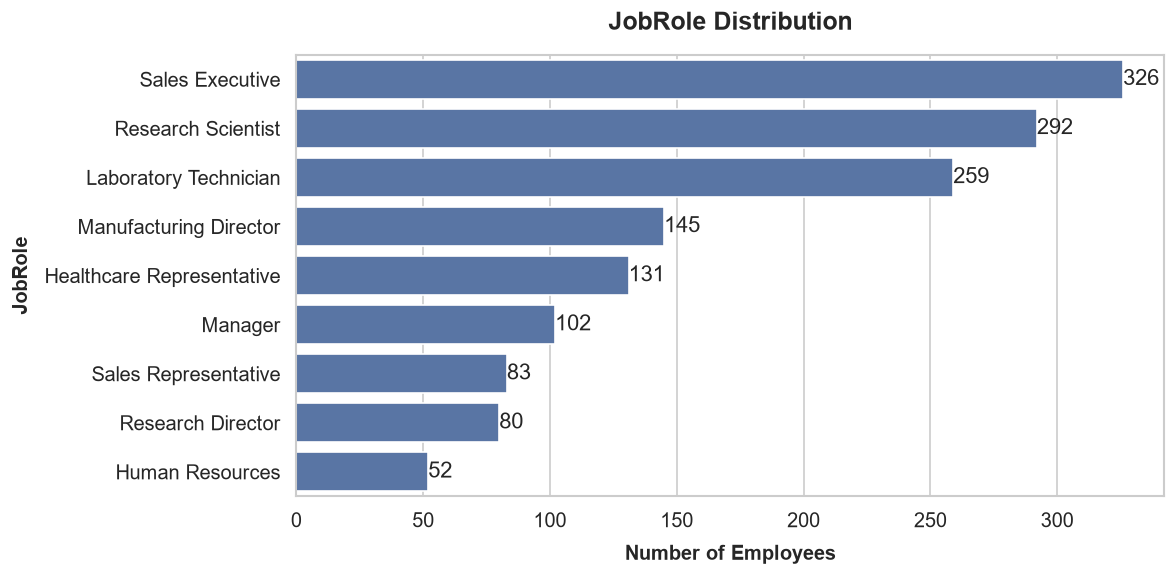

In [29]:
plot_categorical_feature(df, "JobRole")

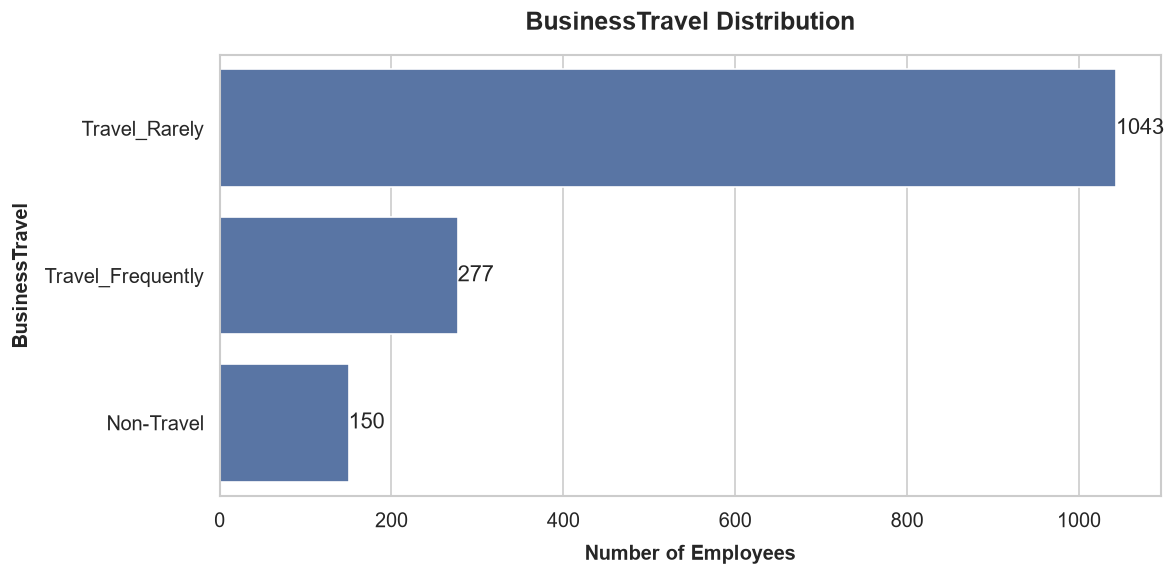

In [30]:
plot_categorical_feature(df, "BusinessTravel")

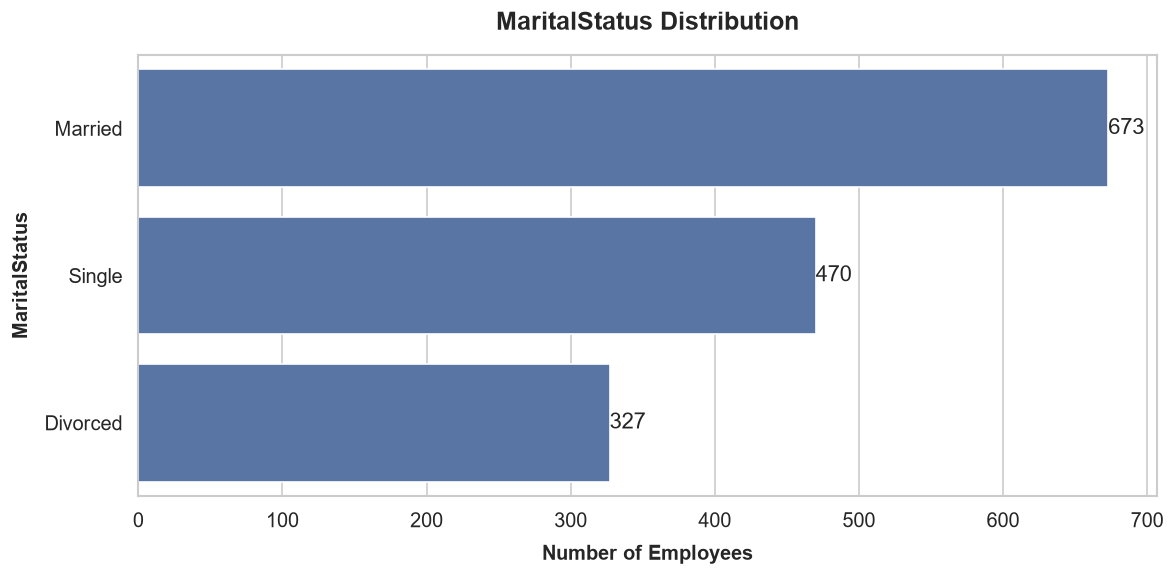

In [31]:
plot_categorical_feature(df, "MaritalStatus")

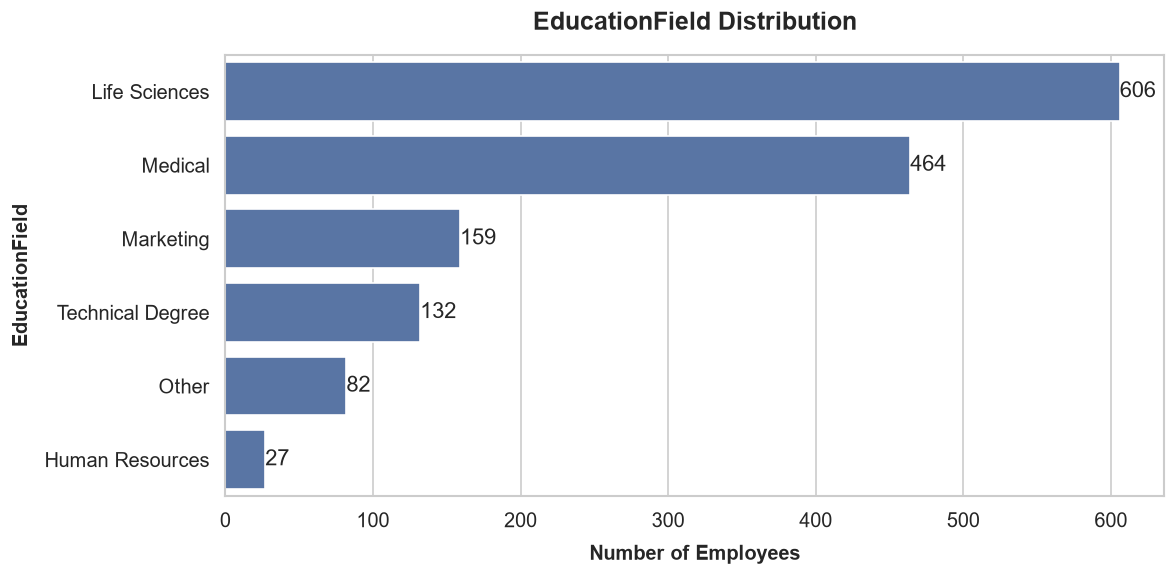

In [32]:
plot_categorical_feature(df, "EducationField")

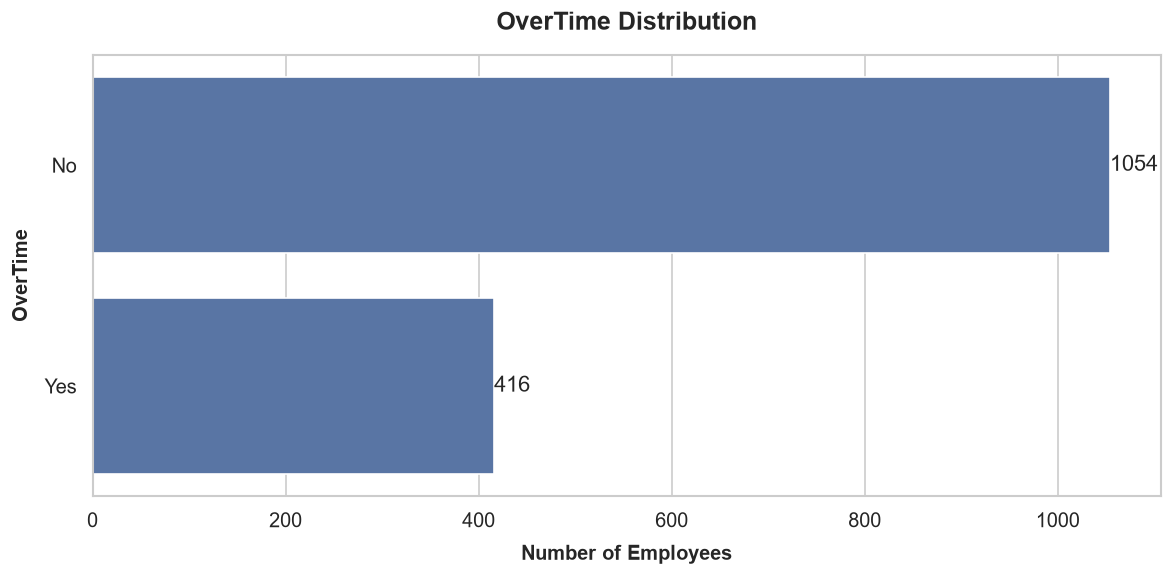

In [33]:
plot_categorical_feature(df, "OverTime")

### Interpretation

The categorical feature distributions provide an overview of the workforce composition.

These visualizations highlight how employees are distributed across departments, job roles, education fields, marital status, business travel frequency, and overtime categories.

Understanding these distributions helps identify dominant employee groups and provides context for later analyses examining their relationship with employee attrition.

### Business Insight

The categorical distributions reveal important characteristics of the organization's workforce.

While these charts describe employee composition, they do not indicate which groups experience higher attrition. This relationship will be explored in the next section through comparative analyses between employee characteristics and attrition status.

These findings provide HR professionals with an overview of organizational demographics before investigating the drivers of employee turnover.

# Relationship Between Employee Characteristics and Attrition

## Overview

While the previous sections explored individual feature distributions, they did not explain which employee groups are more likely to leave the organization.

In this section, we compare important employee characteristics with the target variable (**Attrition**) to identify patterns associated with employee turnover.

The objective is to discover actionable insights that can help Human Resources (HR) improve employee retention strategies.

In [34]:
# HELPER FUNCTION: CATEGORICAL FEATURE VS ATTRITION

def plot_attrition_relationship(data, feature):
    """
    Plot the relationship between a categorical feature and employee attrition.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset containing the feature.

    feature : str
        Feature to compare with Attrition.
    """

    plt.figure(figsize=(10, 6))

    ax = sns.countplot(
        data=data,
        x=feature,
        hue=TARGET_COLUMN,
        palette="Set2"
    )

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container)

    plt.title(
        f"{feature} vs Employee Attrition",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Employees")
    plt.xticks(rotation=15)

    plt.legend(title="Attrition")

    plt.tight_layout()
    plt.savefig(
    f"charts/{column.lower()}_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

## Overtime vs Employee Attrition

Overtime is one of the most important workplace factors that may influence employee retention.

Employees who consistently work overtime may experience increased stress, fatigue, and reduced work-life balance, making them more likely to leave the organization.

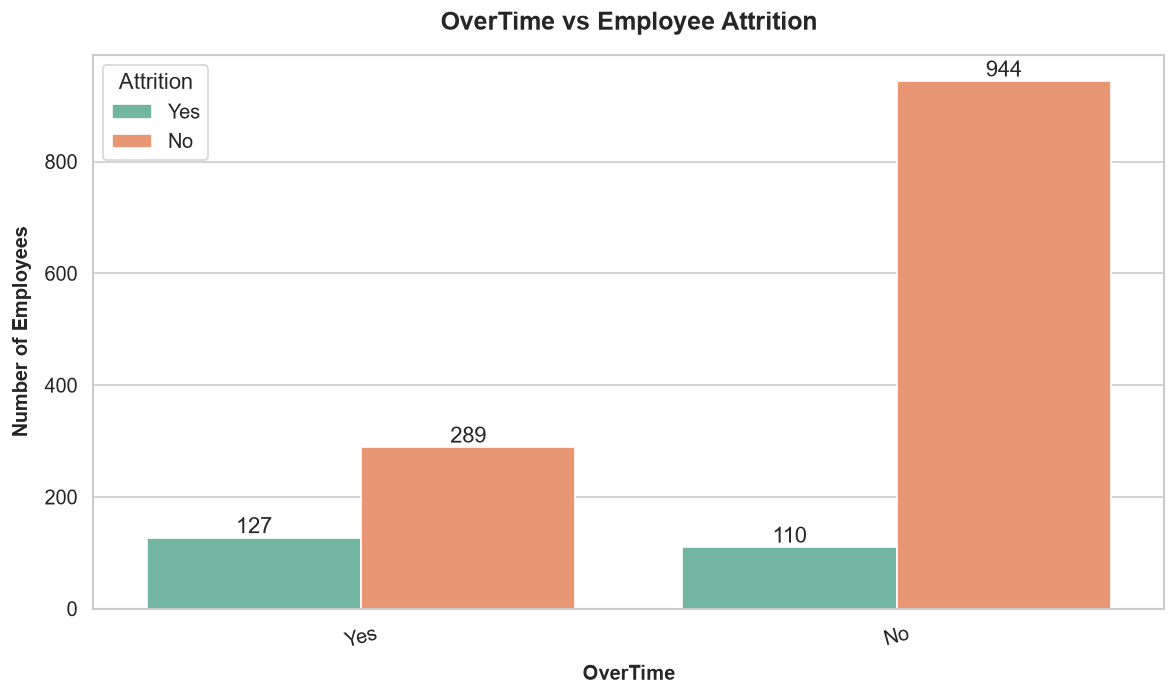

In [35]:
plot_attrition_relationship(df, "OverTime")

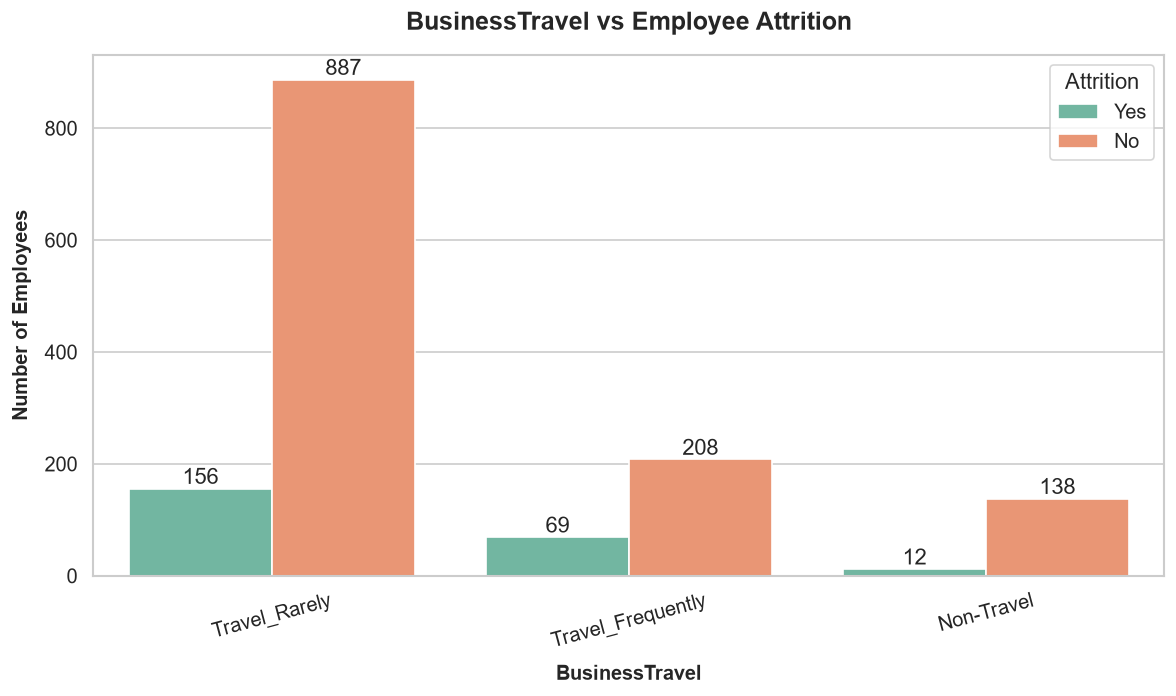

In [36]:
plot_attrition_relationship(df, "BusinessTravel")

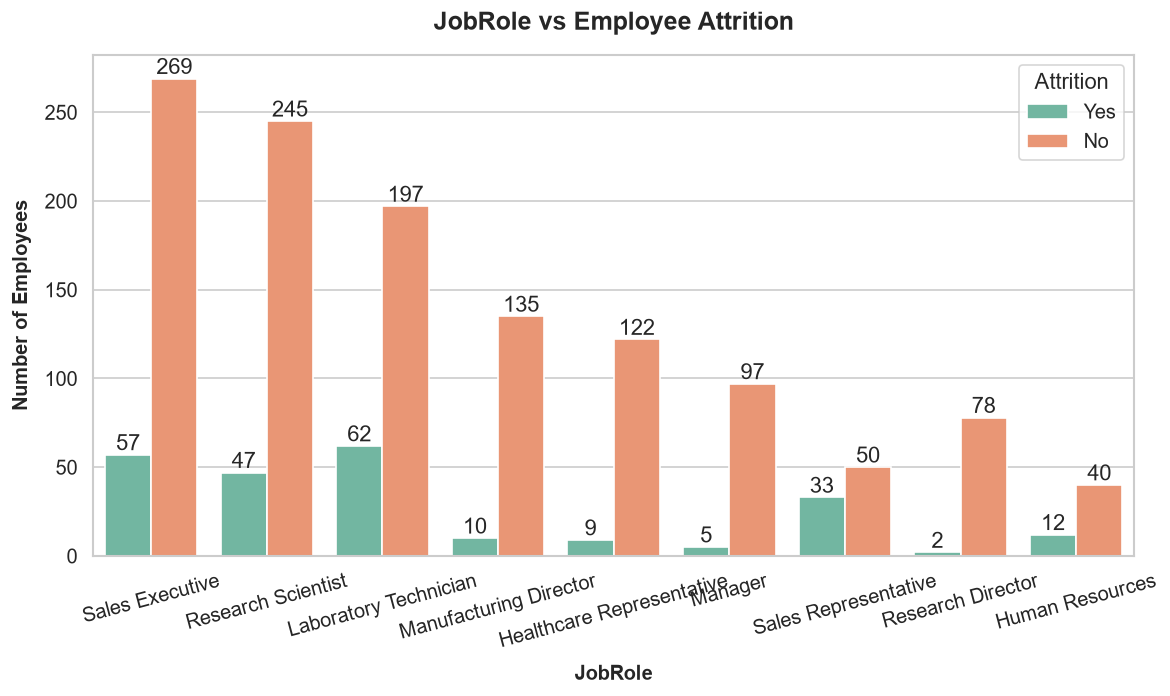

In [37]:
plot_attrition_relationship(df, "JobRole")

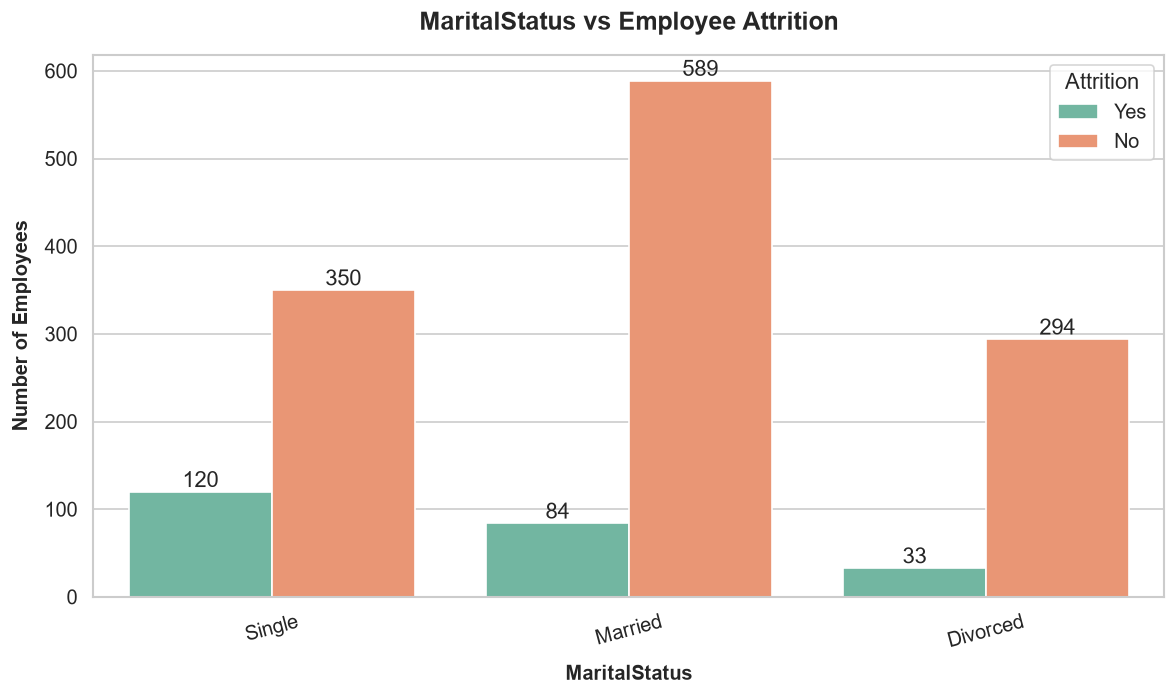

In [38]:
plot_attrition_relationship(df, "MaritalStatus")

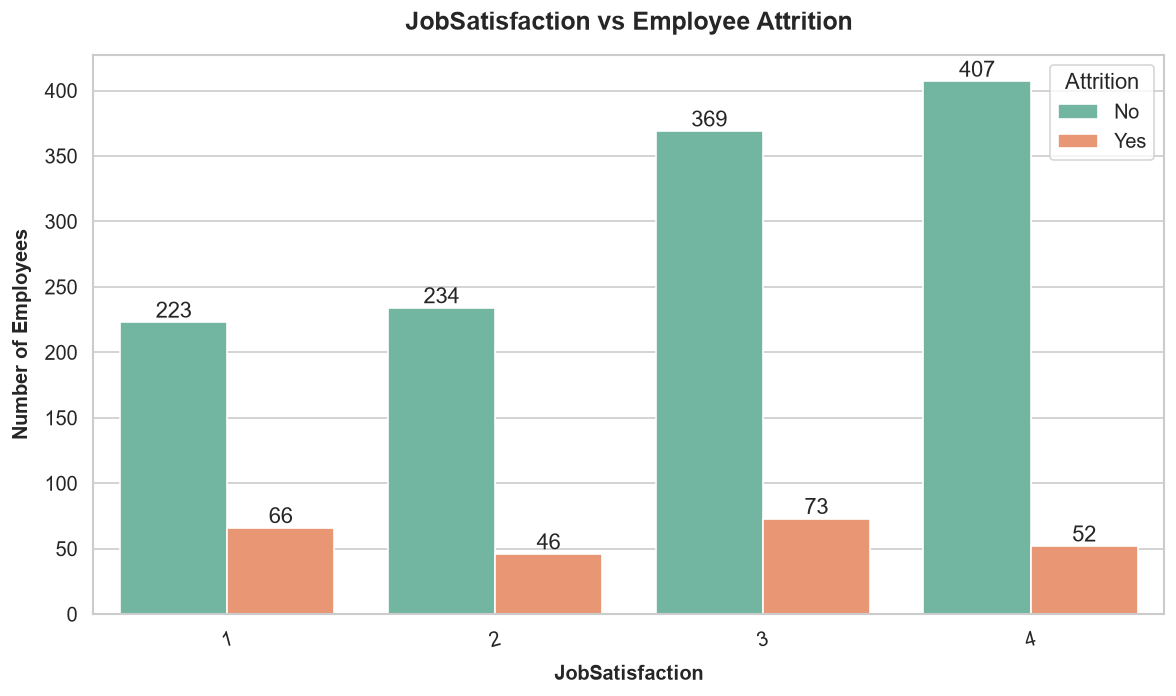

In [39]:
plot_attrition_relationship(df, "JobSatisfaction")

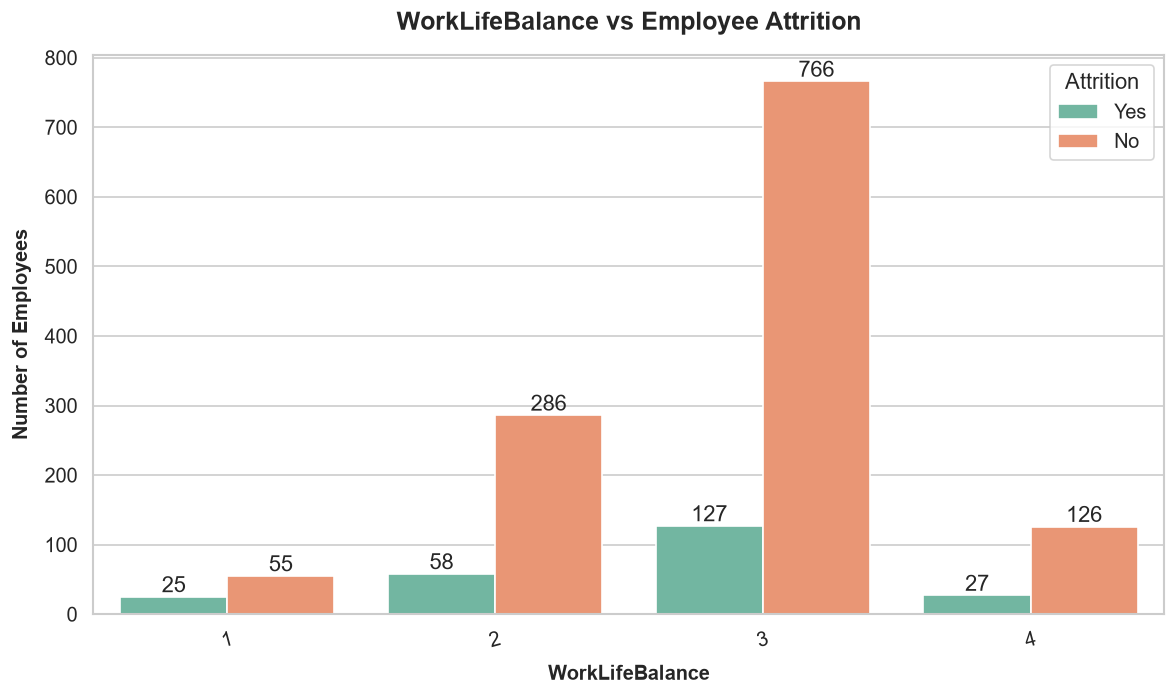

In [40]:
plot_attrition_relationship(df, "WorkLifeBalance")

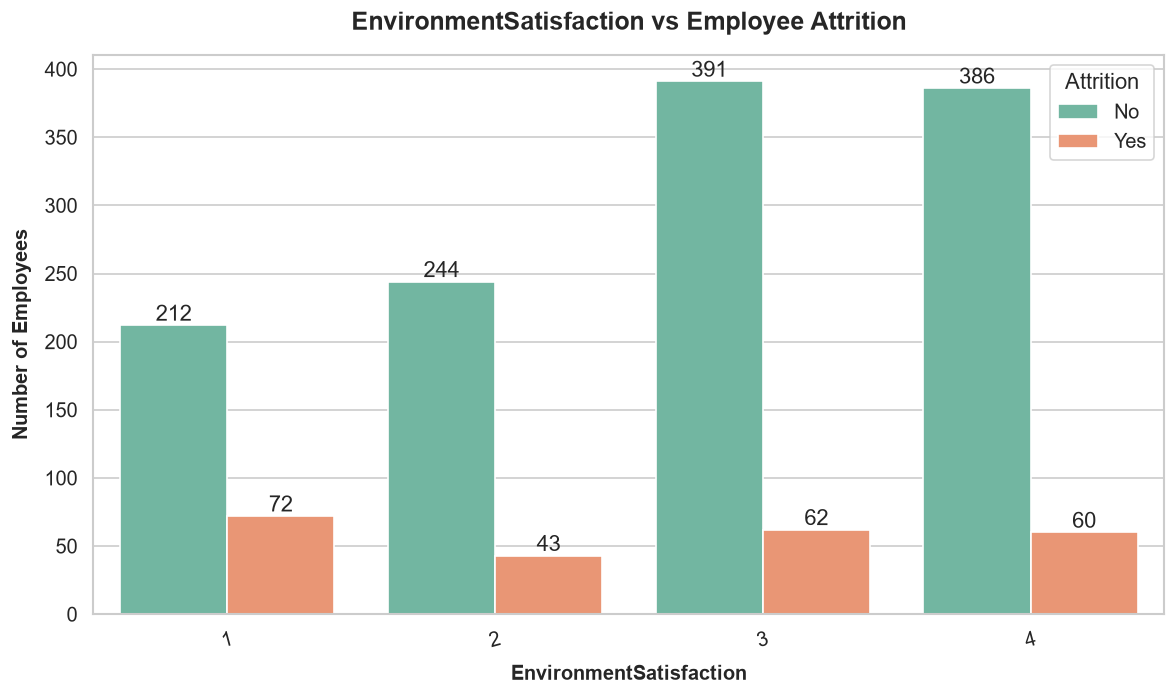

In [41]:
plot_attrition_relationship(df, "EnvironmentSatisfaction")

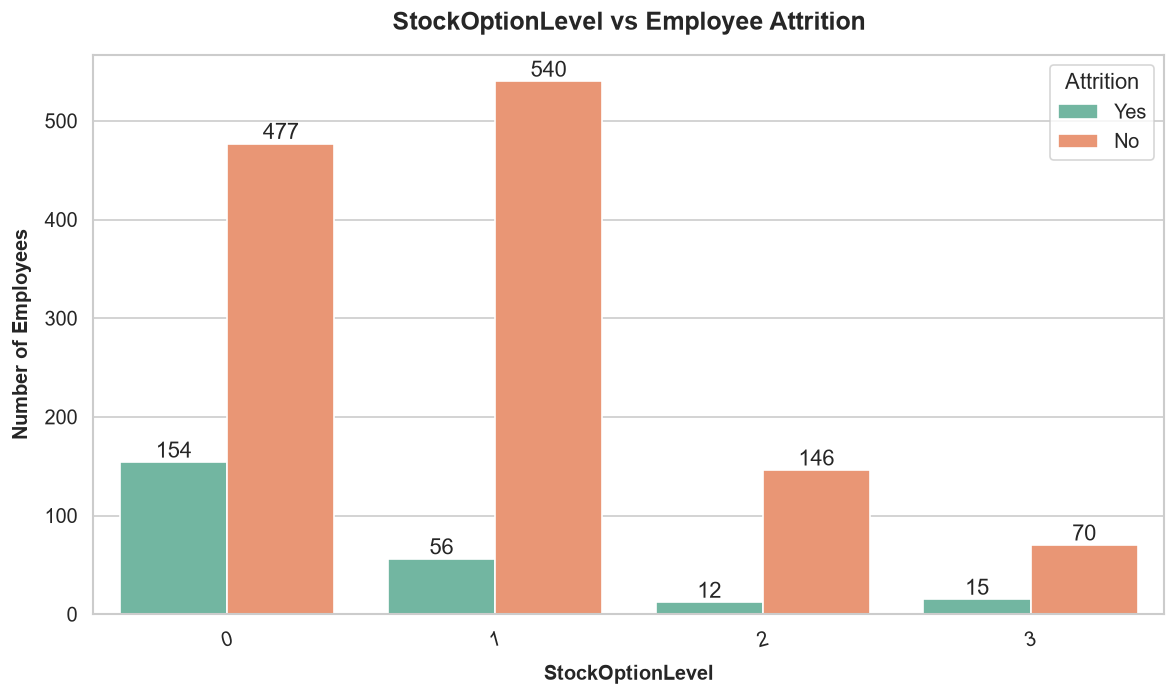

In [42]:
plot_attrition_relationship(df, "StockOptionLevel")

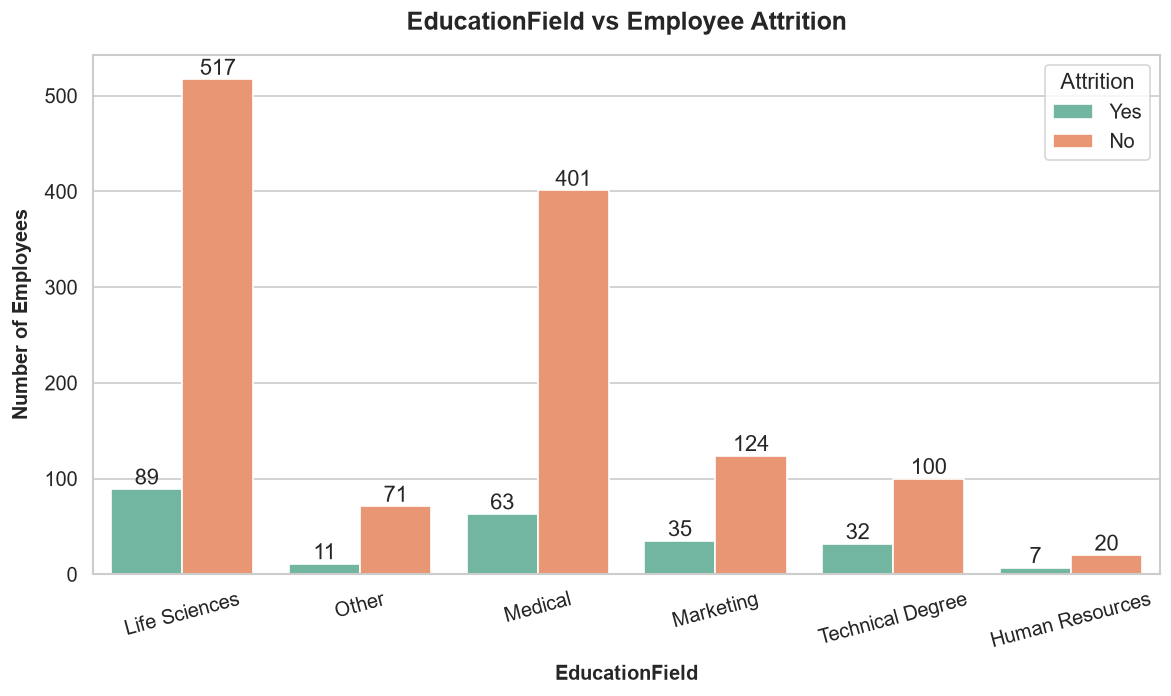

In [43]:
plot_attrition_relationship(df, "EducationField")

## Interpretation

Comparing employee characteristics with attrition reveals which groups experience higher turnover.

Features such as overtime, business travel frequency, job satisfaction, work-life balance, and department are expected to have a strong influence on employee attrition.

These insights help identify high-risk employee groups and provide a foundation for building predictive machine learning models.

## Business Insight

The relationship analysis highlights the employee groups that may require additional attention from Human Resources.

For example:

- Employees working overtime may require workload management.
- Employees with lower job satisfaction may benefit from engagement initiatives.
- Certain departments or job roles may experience higher turnover and require targeted retention strategies.

These insights allow organizations to allocate HR resources more effectively and implement evidence-based retention policies.

# Correlation Analysis

## Overview

Correlation analysis measures the strength and direction of the relationship between numerical variables.

A correlation heatmap helps identify highly correlated features, detect potential multicollinearity, and understand the relationships among employee characteristics.

Although correlation does not imply causation, it provides valuable insights into how variables are related and supports feature selection during model development.

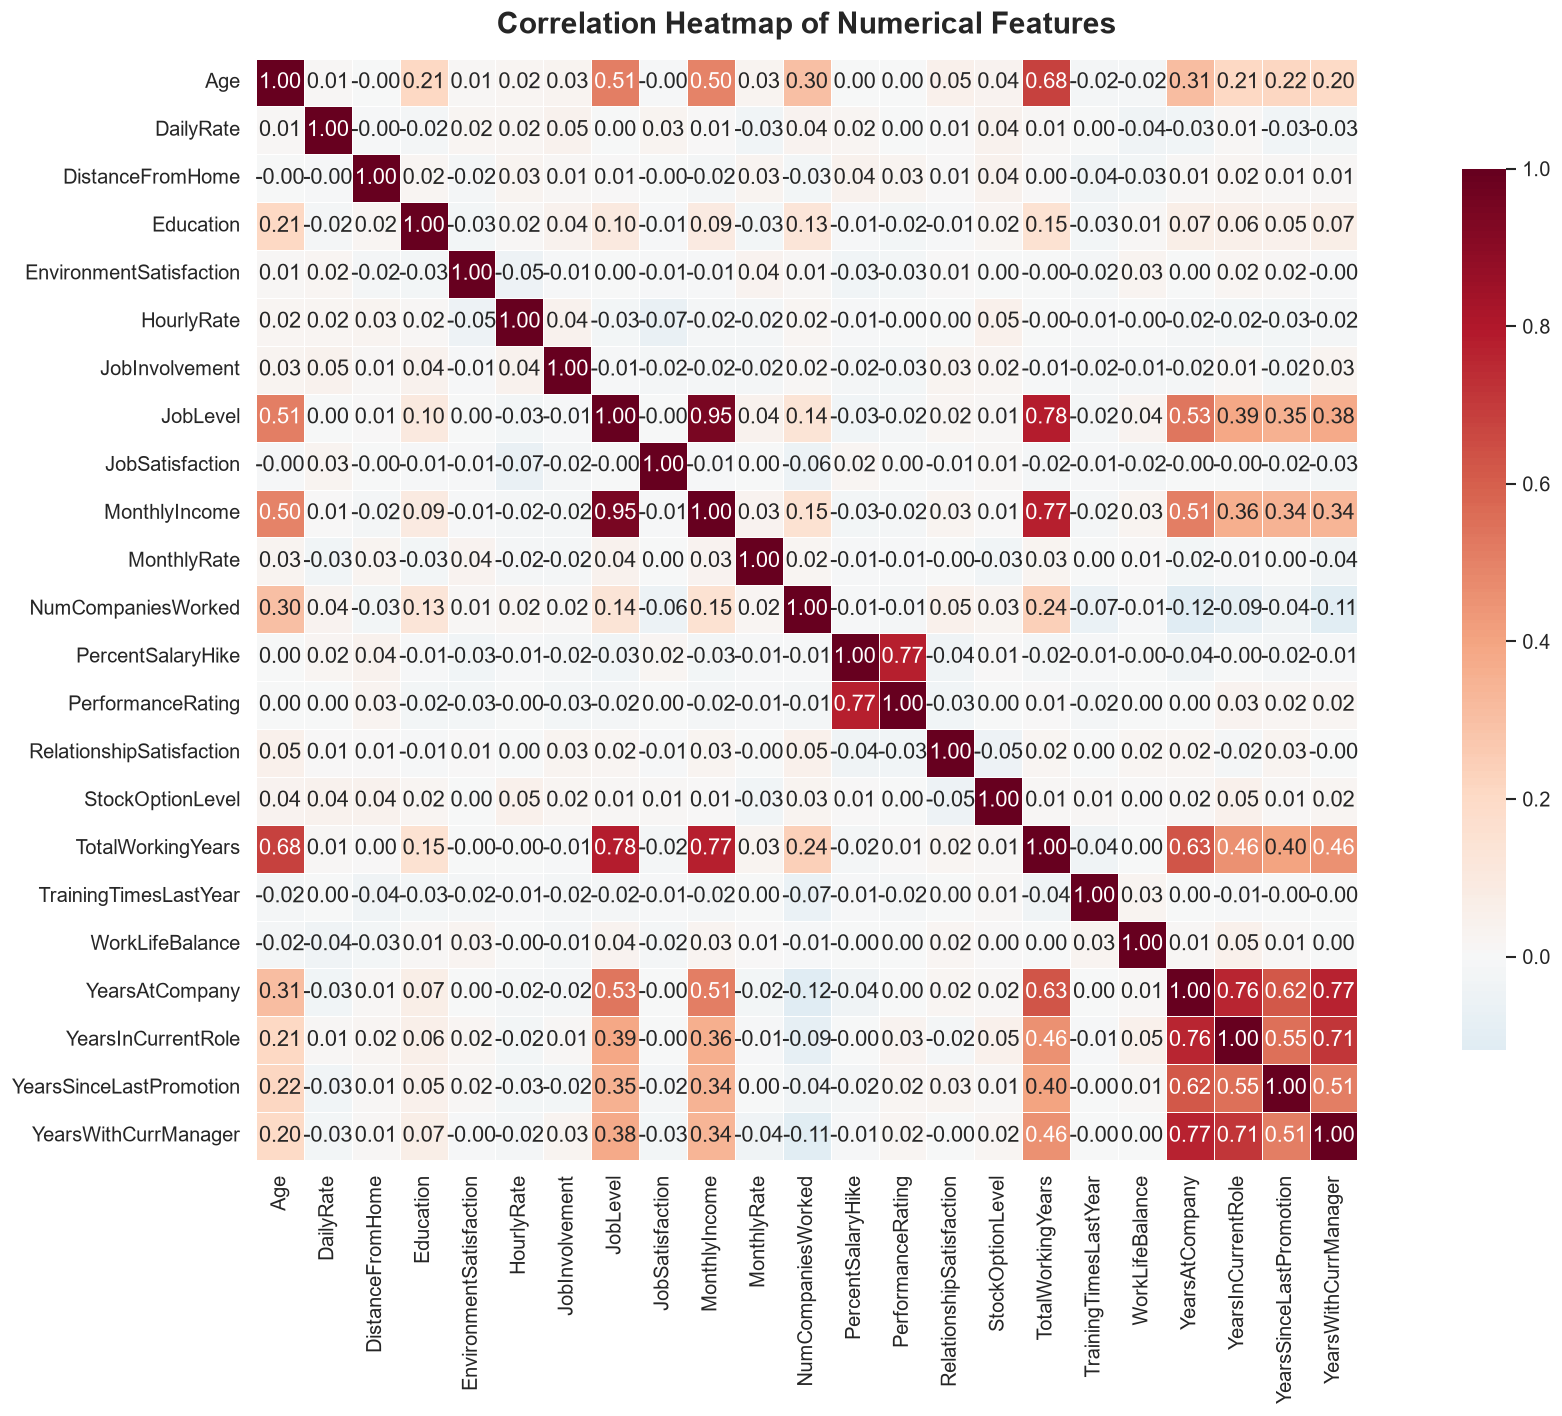

In [44]:
# SECTION 6.5: CORRELATION HEATMAP

# Select only numerical features
numerical_features = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
correlation_matrix = numerical_features.corr()

# Plot heatmap
plt.figure(figsize=(18, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    f"charts/{column.lower()}_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Interpretation

The correlation heatmap illustrates the pairwise relationships between numerical variables.

Correlation values range from **-1** to **+1**:

- **+1** indicates a perfect positive correlation.
- **-1** indicates a perfect negative correlation.
- **0** indicates no linear relationship.

Most features in the IBM HR Analytics dataset exhibit weak to moderate correlations, suggesting that they capture different aspects of employee behavior and organizational characteristics.

Some tenure-related variables, such as **YearsAtCompany**, **YearsInCurrentRole**, and **YearsWithCurrManager**, may display stronger positive correlations because they represent related measures of employee experience.

## Business Insight

The correlation analysis indicates that most employee attributes provide unique information rather than duplicating one another.

This is beneficial because machine learning models can learn from multiple independent factors influencing employee attrition.

Highly correlated tenure-related features are expected, as employees with longer service often spend more years in their current role and with the same manager.

These relationships reflect natural organizational career progression rather than data quality issues.

## Why This Matters in HR Analytics

Correlation analysis helps HR analysts understand how workforce characteristics are related.

However, correlation alone cannot determine the cause of employee attrition. Business interpretation and predictive modeling are required to identify the most influential factors contributing to employee turnover.

# Feature Engineering

## Overview

Feature engineering involves preparing the dataset for machine learning by transforming or selecting features that improve model performance.

For the IBM HR Analytics Employee Attrition dataset, the data is already well-structured and contains meaningful employee attributes. Therefore, extensive feature engineering is not required.

Instead, this section focuses on identifying the target variable and preparing categorical features for machine learning algorithms.

## Why Minimal Feature Engineering?

Unlike many real-world datasets, the IBM HR Analytics dataset is already cleaned and structured.

The dataset does not require:

- Date feature extraction
- Text preprocessing
- Missing value imputation
- Complex feature generation

The primary preprocessing task is converting categorical variables into numerical representations so they can be used by machine learning algorithms.

In [45]:
# IDENTIFY CATEGORICAL FEATURES

categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical Features")

print(f"Total Categorical Features : {len(categorical_columns)}\n")

for column in categorical_columns:
    print(f"• {column}")

Categorical Features
Total Categorical Features : 8

• Attrition
• BusinessTravel
• Department
• EducationField
• Gender
• JobRole
• MaritalStatus
• OverTime


### Interpretation

The identified categorical features represent employee characteristics such as department, job role, business travel frequency, overtime status, and marital status.

Machine learning algorithms require numerical input; therefore, these variables will be encoded in the next section.

In [46]:
# IDENTIFY NUMERICAL FEATURES

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical Features")

print(f"Total Numerical Features : {len(numerical_columns)}\n")

for column in numerical_columns:
    print(f"• {column}")

Numerical Features
Total Numerical Features : 23

• Age
• DailyRate
• DistanceFromHome
• Education
• EnvironmentSatisfaction
• HourlyRate
• JobInvolvement
• JobLevel
• JobSatisfaction
• MonthlyIncome
• MonthlyRate
• NumCompaniesWorked
• PercentSalaryHike
• PerformanceRating
• RelationshipSatisfaction
• StockOptionLevel
• TotalWorkingYears
• TrainingTimesLastYear
• WorkLifeBalance
• YearsAtCompany
• YearsInCurrentRole
• YearsSinceLastPromotion
• YearsWithCurrManager


### Business Insight

The dataset contains a combination of numerical and categorical employee attributes.

This combination allows machine learning models to learn from multiple aspects of employee behavior, including demographics, compensation, work environment, job satisfaction, and organizational characteristics.

Proper preprocessing of these features is essential for building reliable predictive models.

# Feature Encoding

## Overview

Machine learning algorithms require numerical input features. However, the IBM HR Analytics dataset contains several categorical variables represented as text.

To prepare the dataset for model training, categorical variables are converted into numerical representations.

In this project:

- The target variable (**Attrition**) is encoded using **Label Encoding**.
- The predictor variables are encoded using **One-Hot Encoding** (`pd.get_dummies()`).

This approach preserves the categorical nature of the features while avoiding the introduction of artificial ordinal relationships.

In [47]:
# SECTION 8: ENCODE TARGET VARIABLE

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Encode the target variable
df[TARGET_COLUMN] = label_encoder.fit_transform(df[TARGET_COLUMN])

print("Target Variable Encoded Successfully")

print("Encoding Mapping:")

for original, encoded in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{original} → {encoded}")

Target Variable Encoded Successfully
Encoding Mapping:
No → 0
Yes → 1


### Interpretation

The target variable has been converted into numerical format.

Encoding Mapping:

- No → 0
- Yes → 1

The encoded target variable is now suitable for binary classification models.

In [48]:
# ONE-HOT ENCODE CATEGORICAL FEATURES

# Encode categorical predictor variables
df_encoded = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)
print("Categorical Features Encoded Successfully")

print(f"Original Dataset Shape : {df.shape}")
print(f"Encoded Dataset Shape  : {df_encoded.shape}")

Categorical Features Encoded Successfully
Original Dataset Shape : (1470, 31)
Encoded Dataset Shape  : (1470, 45)


In [49]:
# Display first five rows of the encoded dataset
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,0,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0


### Interpretation

One-Hot Encoding converts each categorical feature into one or more binary indicator variables.

Using `drop_first=True` removes one category from each feature to avoid multicollinearity, also known as the **dummy variable trap**, which is particularly important for linear models such as Logistic Regression.

The encoded dataset now contains only numerical features and is ready for machine learning.

## Why One-Hot Encoding Instead of Label Encoding?

Label Encoding assigns arbitrary integer values to categories.

For example:

| Department | Label Encoded |
|------------|--------------:|
| HR | 0 |
| Sales | 1 |
| Research & Development | 2 |

This incorrectly implies an order:

HR < Sales < Research

In reality, these departments have **no natural ranking**.

One-Hot Encoding avoids this issue by creating separate binary columns for each category.

This preserves the categorical nature of the data and generally leads to better performance for models such as Logistic Regression.

# Train-Test Split

## Overview

Before training machine learning models, the dataset is divided into training and testing subsets.

- **Training Set:** Used to train the machine learning models.
- **Testing Set:** Used to evaluate the model on unseen data.

A **stratified train-test split** is used to preserve the original distribution of the target classes in both subsets. This is particularly important because the employee attrition dataset is not perfectly balanced.

Separating the data before model training helps evaluate how well the model generalizes to new, unseen employee records.

In [50]:
# SECTION 9: FEATURE SELECTION

# Define feature matrix (X) and target vector (y)
X = df_encoded.drop(columns=TARGET_COLUMN)
y = df_encoded[TARGET_COLUMN]

print("FEATURE MATRIX & TARGET VARIABLE")
print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

FEATURE MATRIX & TARGET VARIABLE
Feature Matrix Shape : (1470, 44)
Target Vector Shape  : (1470,)


### Interpretation

The dataset has now been separated into:

- **Feature Matrix (X):** Contains all predictor variables.
- **Target Vector (y):** Contains the employee attrition labels.

This separation is required before splitting the data into training and testing subsets.

In [51]:
# SECTION 10: TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("TRAIN-TEST SPLIT COMPLETED")
print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Labels   : {y_train.shape}")
print(f"Testing Labels    : {y_test.shape}")

TRAIN-TEST SPLIT COMPLETED
Training Features : (1176, 44)
Testing Features  : (294, 44)
Training Labels   : (1176,)
Testing Labels    : (294,)


In [52]:
# SECTION 10b: CROSS-VALIDATION CHECK
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'),
    X, y,
    cv=cv_strategy,
    scoring='roc_auc'
)

print("5-FOLD CROSS-VALIDATION (Logistic Regression, ROC-AUC)")
print(f"Fold scores : {cv_scores.round(3)}")
print(f"Mean ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

5-FOLD CROSS-VALIDATION (Logistic Regression, ROC-AUC)
Fold scores : [0.714 0.75  0.794 0.793 0.752]
Mean ROC-AUC: 0.761 (+/- 0.030)


### Interpretation

The dataset has been successfully divided into training and testing subsets.

Using **stratified sampling** ensures that the proportion of employees who stayed and those who left remains consistent across both subsets. This leads to a more reliable evaluation of model performance.

# Feature Scaling

## Overview

Feature scaling standardizes numerical variables so that they have a similar range.

Scaling is important for algorithms such as **Logistic Regression**, which are sensitive to differences in feature magnitude.

Tree-based algorithms such as Decision Tree, Random Forest, and Gradient Boosting do not require feature scaling because they split data based on feature values rather than distances.

In [53]:
# SECTION 11: FEATURE SCALING

# Initialize StandardScaler
scaler = StandardScaler()

# Scale features for Logistic Regression
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("FEATURE SCALING COMPLETED")
print(f"Scaled Training Shape : {X_train_scaled.shape}")
print(f"Scaled Testing Shape  : {X_test_scaled.shape}")

FEATURE SCALING COMPLETED
Scaled Training Shape : (1176, 44)
Scaled Testing Shape  : (294, 44)


### Interpretation

Feature scaling has been applied using **StandardScaler**.

The scaler was fitted only on the training data and then used to transform both the training and testing datasets. This prevents **data leakage**, ensuring that information from the test set does not influence the training process.

The scaled datasets will be used for Logistic Regression, while the original unscaled datasets will be used for tree-based models.

# Model Building

## Overview

In this section, multiple machine learning classification algorithms are trained and evaluated to predict employee attrition.

The following models will be implemented:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

To ensure consistency and reduce code duplication, a reusable model evaluation function is created. This function evaluates each model using the same performance metrics and visualization techniques.

Using a common evaluation framework allows for a fair comparison of model performance.

In [54]:
# HELPER FUNCTION: MODEL EVALUATION

def evaluate_model(model, X_train, X_test, y_train, y_test, sample_weight=None):
    """
    Train and evaluate a classification model.

    Parameters
    ----------
    model : sklearn estimator
        Machine learning model.

    X_train : Training features
    X_test : Testing features
    y_train : Training labels
    y_test : Testing labels
    """

    # Train model
    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Prediction probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Performance Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Print Results
    print(f"{model.__class__.__name__}")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues",
        colorbar=False
    )

    plt.title(f"{model.__class__.__name__} - Confusion Matrix")
    plt.savefig(
    f"charts/{model.__class__.__name__.lower()}_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(7,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {roc_auc:.3f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model.__class__.__name__} - ROC Curve")

    plt.legend()

    plt.grid(True)
    plt.savefig(
    f"charts/{model.__class__.__name__.lower()}_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

    # Return metrics
    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

### Why Create a Reusable Evaluation Function?

Instead of writing separate evaluation code for each machine learning model, a reusable evaluation function has been created.

This approach offers several advantages:

- Reduces repetitive code.
- Ensures that all models are evaluated using identical metrics.
- Improves code readability and maintainability.
- Makes it easier to compare different machine learning models fairly.

This modular approach follows software engineering best practices and is commonly used in professional machine learning workflows.

# Model Performance Tracking

To compare all machine learning models fairly, their evaluation metrics will be stored in a common list.

After each model is evaluated, its performance metrics will be appended to this list.

At the end of the project, these results will be converted into a summary table for comparison.

In [55]:
# INITIALIZE MODEL RESULTS

# List to store evaluation metrics for all machine learning models
model_results = []

# Logistic Regression

## Overview

Logistic Regression is one of the most widely used algorithms for binary classification problems.

Since employee attrition has two possible outcomes (**Yes** or **No**), Logistic Regression serves as an excellent baseline model.

Because Logistic Regression is sensitive to the scale of the input features, the standardized dataset (`X_train_scaled` and `X_test_scaled`) is used for training and evaluation.

LogisticRegression
Accuracy : 0.7517
Precision: 0.3452
Recall   : 0.6170
F1 Score : 0.4427
ROC-AUC  : 0.7983

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



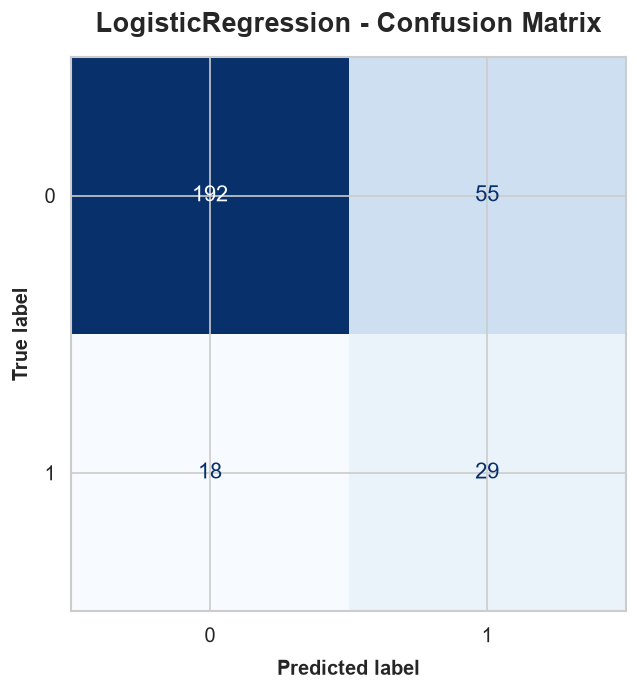

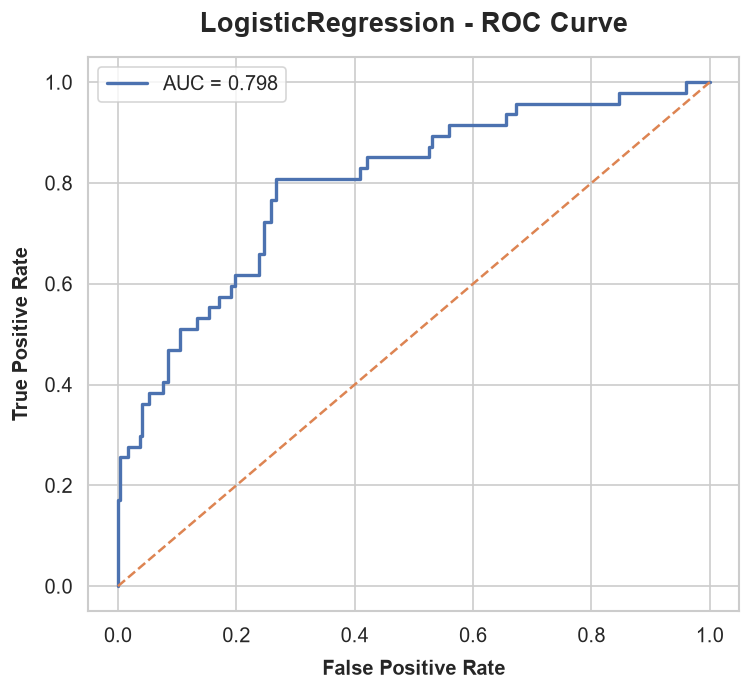

In [56]:
# SECTION 12: LOGISTIC REGRESSION

# Initialize model
logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)

# Train and evaluate
logistic_results = evaluate_model(
    model=logistic_model,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test
)

### Interpretation

Logistic Regression provides a strong baseline for evaluating employee attrition prediction.

The model estimates the probability that an employee belongs to the attrition class and classifies employees accordingly.

The evaluation metrics and confusion matrix provide insights into how effectively the model distinguishes between employees who stay and those who leave.

### Advantages

- Simple and easy to interpret.
- Fast to train.
- Works well for binary classification.
- Produces probability estimates.
- Provides a strong baseline for comparison with more complex models.

### Limitations

- Assumes a linear relationship between features and the log-odds of the target.
- May not capture complex interactions between employee characteristics.
- Performance can be lower than ensemble methods for complex datasets.

### Business Insight

Logistic Regression establishes a baseline for predicting employee attrition.

Although more advanced models may achieve higher predictive performance, Logistic Regression offers excellent interpretability, allowing HR professionals to understand the influence of employee characteristics on attrition risk.

Its probability estimates can also support early identification of employees who may require retention interventions.

In [57]:
# Store Logistic Regression results
model_results.append(logistic_results)

In [58]:
len(model_results)

1

# Decision Tree

## Overview

Decision Tree is a non-linear supervised machine learning algorithm used for classification and regression tasks.

Unlike Logistic Regression, Decision Trees can capture complex relationships between employee characteristics without requiring feature scaling.

The model makes predictions by recursively splitting the data based on the feature that provides the highest information gain.

DecisionTreeClassifier
Accuracy : 0.7721
Precision: 0.3571
Recall   : 0.5319
F1 Score : 0.4274
ROC-AUC  : 0.6517

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.82      0.86       247
           1       0.36      0.53      0.43        47

    accuracy                           0.77       294
   macro avg       0.63      0.67      0.64       294
weighted avg       0.81      0.77      0.79       294



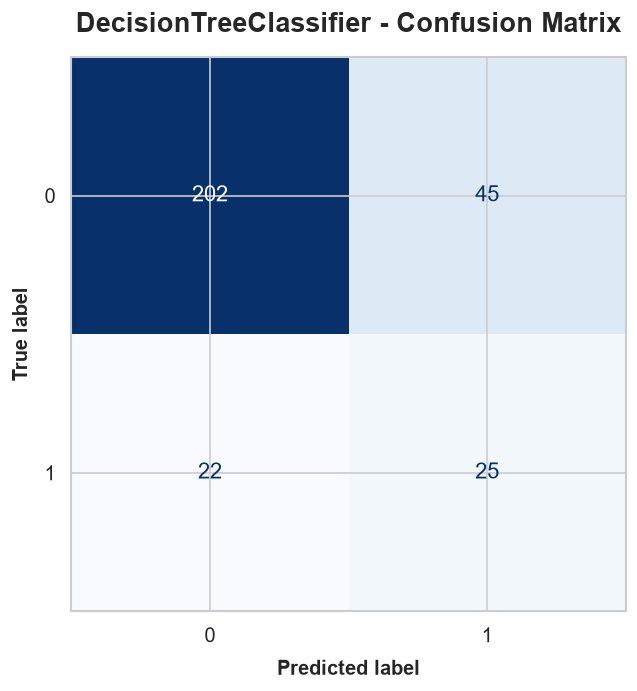

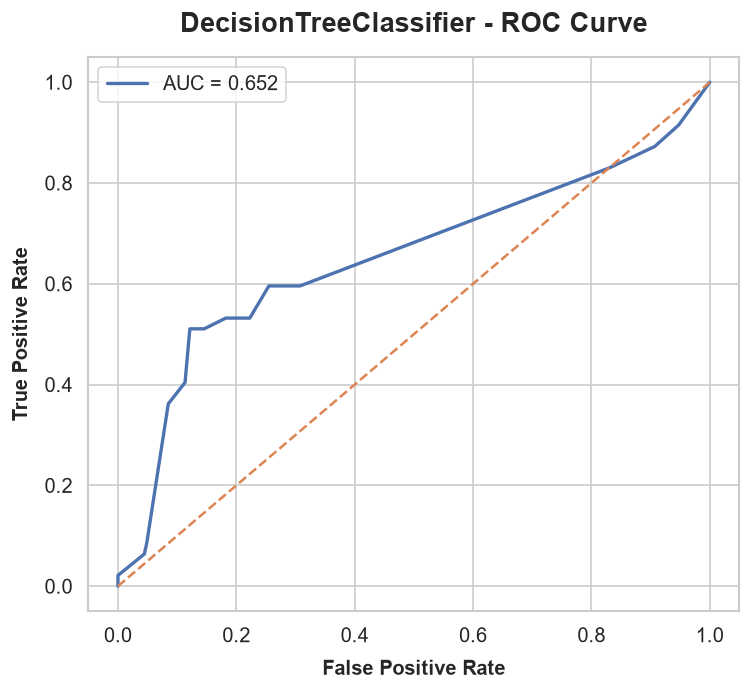

In [59]:
# SECTION 13: DECISION TREE CLASSIFIER

# Initialize Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=5,
    class_weight='balanced'
)

# Train and evaluate the model
decision_tree_results = evaluate_model(
    model=decision_tree_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

# Store model results
model_results.append(decision_tree_results)

### Interpretation

Decision Trees are capable of capturing non-linear relationships between employee attributes and attrition.

Compared with Logistic Regression, Decision Trees often identify more complex decision boundaries. However, they are also more prone to overfitting if not properly controlled.

The confusion matrix and ROC curve illustrate how effectively the model distinguishes between employees who stayed and those who left.

In [60]:
len(model_results)

2

# Random Forest Classifier

## Overview

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve predictive performance and reduce overfitting.

Instead of relying on a single tree, Random Forest trains multiple trees using different subsets of the training data and features. The final prediction is determined by majority voting.

Compared to a single Decision Tree, Random Forest generally provides better accuracy, improved generalization, and greater robustness to noisy data.

Since Random Forest is a tree-based algorithm, feature scaling is not required.

RandomForestClassifier
Accuracy : 0.8265
Precision: 0.4474
Recall   : 0.3617
F1 Score : 0.4000
ROC-AUC  : 0.7655

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       247
           1       0.45      0.36      0.40        47

    accuracy                           0.83       294
   macro avg       0.67      0.64      0.65       294
weighted avg       0.81      0.83      0.82       294



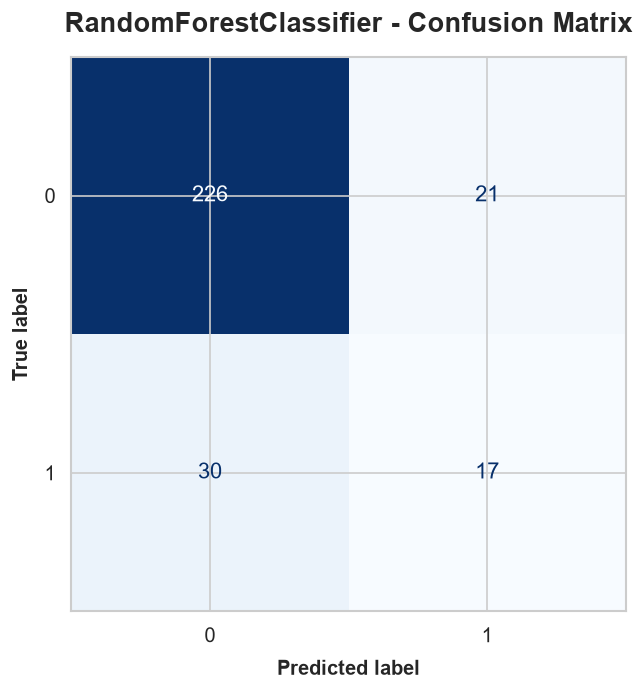

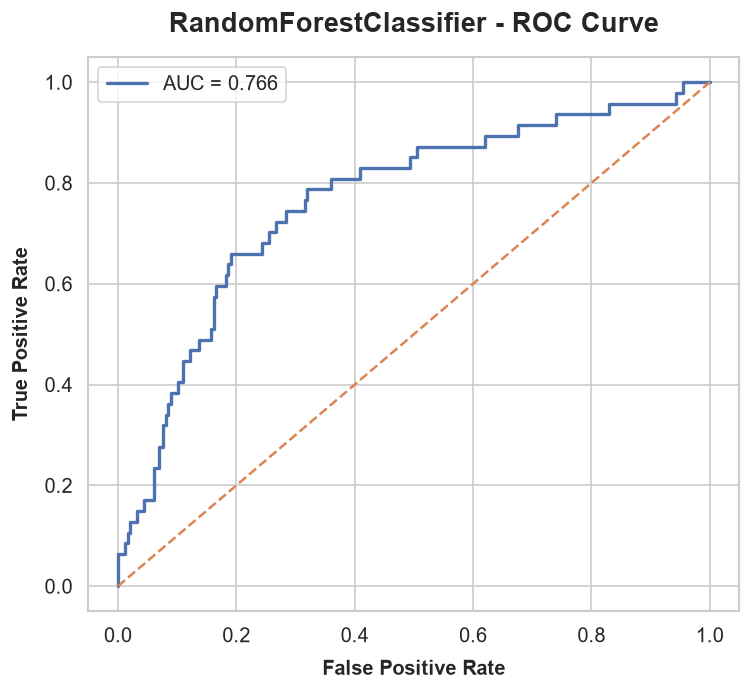

In [61]:
# SECTION 14: RANDOM FOREST CLASSIFIER

# Initialize Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    max_depth=10,
    n_jobs=-1,
    class_weight='balanced'
)   

# Train and evaluate the model
random_forest_results = evaluate_model(
    model=random_forest_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

# Store model results
model_results.append(random_forest_results)

### Interpretation

Random Forest combines the predictions of multiple Decision Trees to improve model stability and predictive performance.

By averaging the predictions of many trees, the algorithm reduces overfitting while maintaining the ability to learn complex relationships within the employee data.

The evaluation metrics provide an indication of how effectively the model identifies employees who are likely to leave the organization.

In [62]:
len(model_results)

3

# Gradient Boosting Classifier

## Overview

Gradient Boosting is an ensemble machine learning algorithm that builds models sequentially.

Each new tree attempts to correct the errors made by the previous trees, allowing the model to progressively improve its predictive performance.

Gradient Boosting is widely used because it can capture complex relationships while achieving high predictive accuracy.

Unlike Logistic Regression, feature scaling is not required because Gradient Boosting is a tree-based algorithm.

GradientBoostingClassifier
Accuracy : 0.8061
Precision: 0.4074
Recall   : 0.4681
F1 Score : 0.4356
ROC-AUC  : 0.7791

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       247
           1       0.41      0.47      0.44        47

    accuracy                           0.81       294
   macro avg       0.65      0.67      0.66       294
weighted avg       0.82      0.81      0.81       294



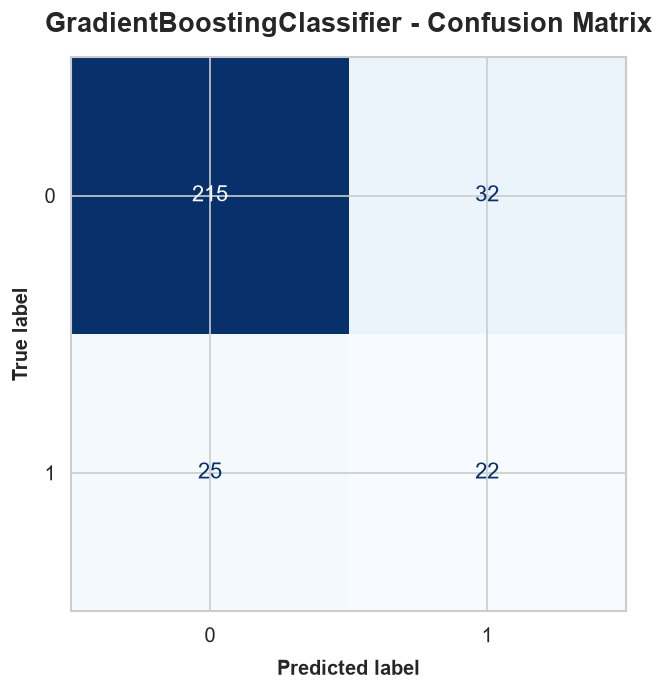

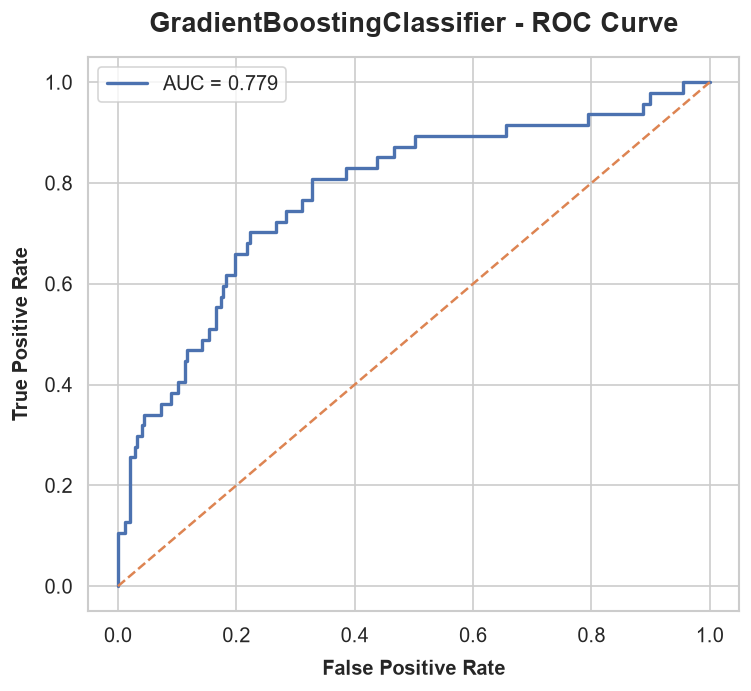

In [63]:
# SECTION 15: GRADIENT BOOSTING CLASSIFIER

# Initialize Gradient Boosting model
gradient_boosting_model = GradientBoostingClassifier(
    random_state=RANDOM_STATE,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

gb_sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Train and evaluate the model
gradient_boosting_results = evaluate_model(
    model=gradient_boosting_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    sample_weight=gb_sample_weight
)

# Store model results
model_results.append(gradient_boosting_results)

### Interpretation

Gradient Boosting builds a sequence of weak learners, where each model focuses on correcting the errors made by the previous model.

This iterative learning process often results in strong predictive performance and makes Gradient Boosting one of the most effective algorithms for structured tabular datasets such as employee attrition data.

In [64]:
len(model_results)

4

# Model Comparison

## Overview

To determine the most suitable model for predicting employee attrition, the performance of all trained models is compared using multiple evaluation metrics.

The following metrics are considered:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

Evaluating multiple metrics provides a more comprehensive assessment than relying on accuracy alone, particularly for datasets with class imbalance.

In [65]:
# MODEL COMPARISON TABLE

# Convert stored model results into a DataFrame
results_df = pd.DataFrame(model_results)

# Sort models by ROC-AUC Score
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

# Display results
results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
    "ROC-AUC": "{:.3f}"
}).background_gradient(
    cmap="Greens",
    subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LogisticRegression,0.752,0.345,0.617,0.443,0.798
1,GradientBoostingClassifier,0.806,0.407,0.468,0.436,0.779
2,RandomForestClassifier,0.827,0.447,0.362,0.400,0.766
3,DecisionTreeClassifier,0.772,0.357,0.532,0.427,0.652


### Interpretation

The comparison table summarizes the performance of all machine learning models using identical evaluation metrics.

Rather than selecting a model based solely on accuracy, additional metrics such as Precision, Recall, F1 Score, and ROC-AUC are considered to provide a balanced assessment of predictive performance.

The model with the highest ROC-AUC score is considered the strongest overall performer.

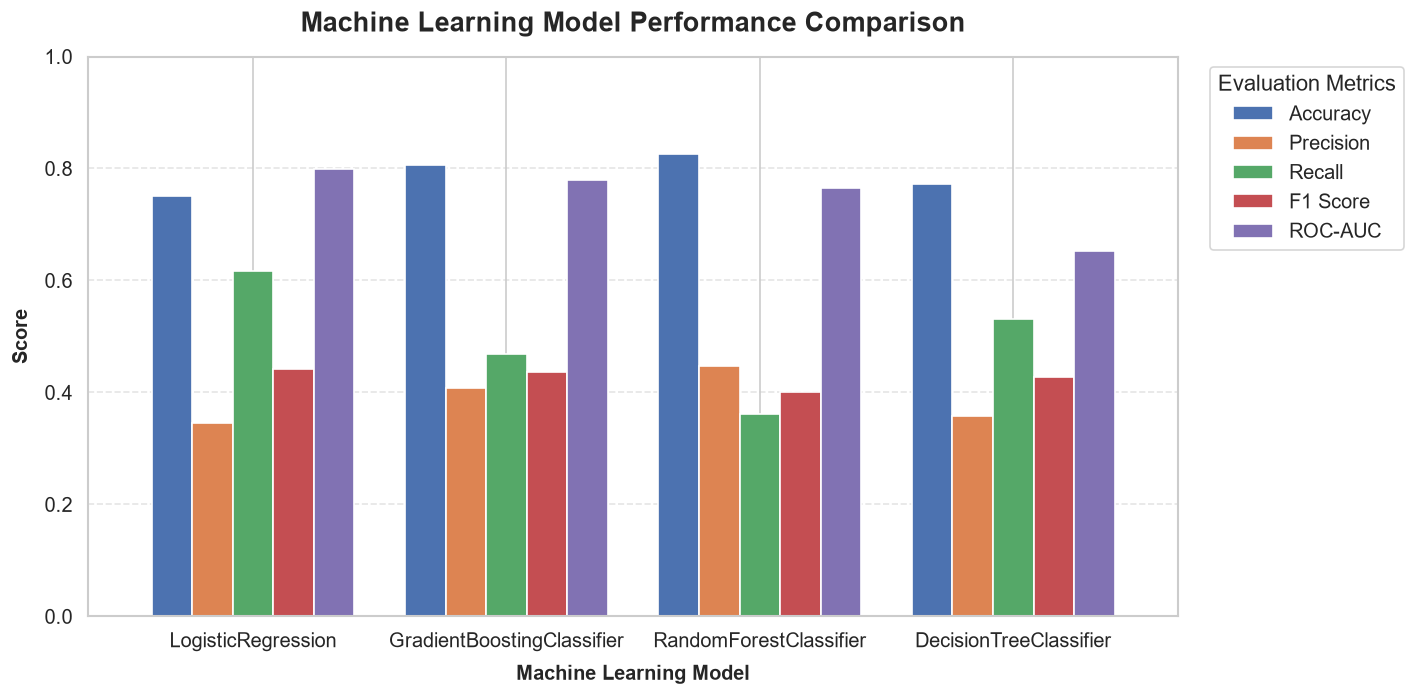

In [66]:
# PERFORMANCE COMPARISON CHART

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_plot = results_df.set_index("Model")[metrics]

ax = results_plot.plot(
    kind="bar",
    figsize=(12,6),
    width=0.8
)

plt.title(
    "Machine Learning Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(
    title="Evaluation Metrics",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(
    "charts/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Interpretation

The bar chart provides a visual comparison of all machine learning models across multiple evaluation metrics.

A model that consistently performs well across Accuracy, Precision, Recall, F1 Score, and ROC-AUC is generally preferred over a model that performs exceptionally well on only one metric.

This comparison enables an objective selection of the most suitable model for employee attrition prediction.


In [67]:
# BEST MODEL

best_model = results_df.iloc[0]

print("BEST PERFORMING MODEL")

print(f"Model     : {best_model['Model']}")
print(f"ROC-AUC   : {best_model['ROC-AUC']:.3f}")
print(f"Accuracy  : {best_model['Accuracy']:.3f}")
print(f"Precision : {best_model['Precision']:.3f}")
print(f"Recall    : {best_model['Recall']:.3f}")
print(f"F1 Score  : {best_model['F1 Score']:.3f}")

BEST PERFORMING MODEL
Model     : LogisticRegression
ROC-AUC   : 0.798
Accuracy  : 0.752
Precision : 0.345
Recall    : 0.617
F1 Score  : 0.443


## Business Insight

Based on the evaluation metrics, the best-performing model demonstrates the strongest ability to distinguish between employees who are likely to stay and those who are likely to leave.

For HR applications, a model with a higher ROC-AUC and balanced Precision and Recall is generally preferred because it can identify at-risk employees more reliably while minimizing incorrect predictions.

Such a model can support proactive retention strategies, workforce planning, and data-driven HR decision-making.

# Feature Importance Analysis

## Overview

Machine learning models can identify which employee characteristics contribute most to predicting employee attrition.

Random Forest is particularly useful because it provides feature importance scores, allowing us to rank features based on their contribution to the prediction process.

Understanding feature importance helps Human Resources (HR) identify the key factors influencing employee turnover and develop targeted retention strategies.

In [68]:
# FEATURE IMPORTANCE

# Extract feature importance scores
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort in descending order
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.08
0,Age,0.06
16,TotalWorkingYears,0.05
43,OverTime_Yes,0.05
19,YearsAtCompany,0.05
1,DailyRate,0.05
22,YearsWithCurrManager,0.05
10,MonthlyRate,0.04
5,HourlyRate,0.04
2,DistanceFromHome,0.04


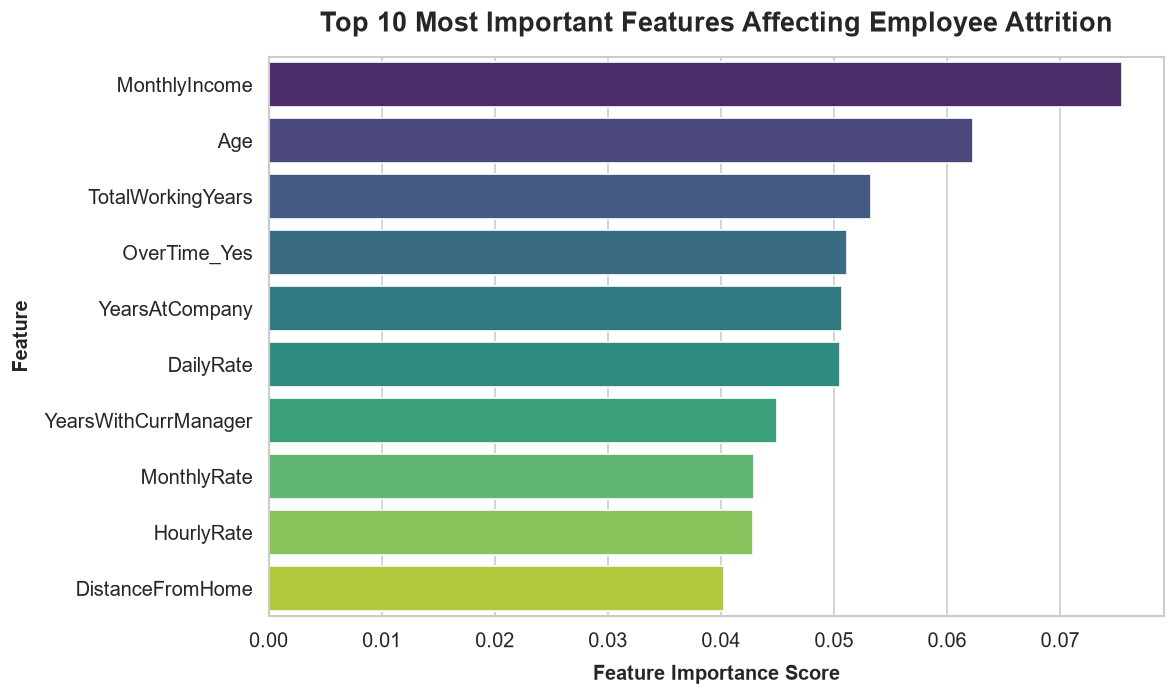

In [69]:
# TOP 10 MOST IMPORTANT FEATURES

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(
    "Top 10 Most Important Features Affecting Employee Attrition",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(
    "charts/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The feature importance chart ranks employee characteristics according to their contribution to the Random Forest model.

Features with higher importance scores have a greater influence on predicting employee attrition.

Rather than indicating cause-and-effect relationships, these scores represent how useful each feature is for making accurate predictions.

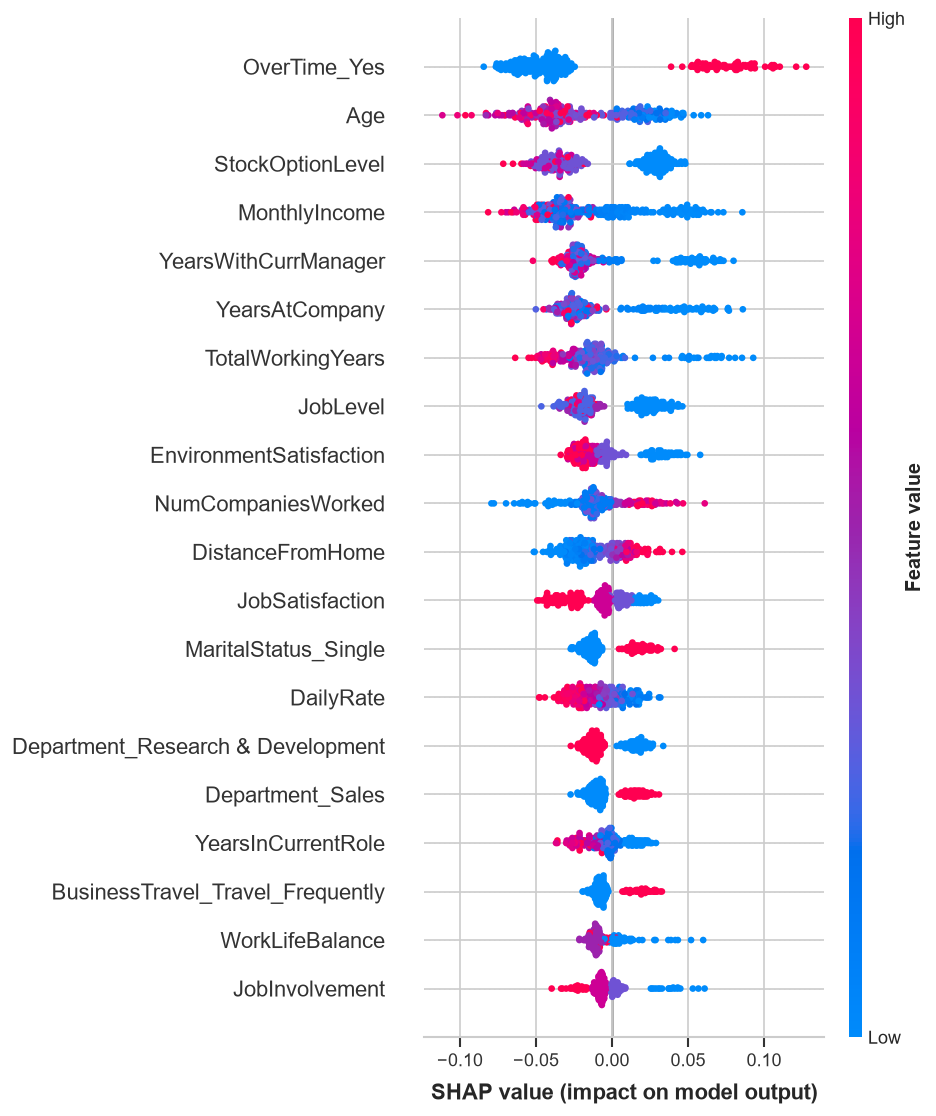

In [70]:
explainer = shap.TreeExplainer(random_forest_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_test, show=False)
plt.tight_layout()
plt.savefig("charts/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation
Each dot represents one employee. Red dots indicate a high value for that feature, blue indicates a low value. Dots pushed to the right increase the predicted likelihood of attrition ("Yes"), while dots pushed to the left decrease it.

## Business Insight

The most influential features should become the primary focus of HR retention strategies.

For example:

- If **OverTime** ranks highly, HR should evaluate employee workload and work-life balance.
- If **MonthlyIncome** is an important feature, compensation policies may require review.
- If **YearsAtCompany** appears among the top predictors, HR can investigate employee retention during different career stages.
- If **JobSatisfaction** or **EnvironmentSatisfaction** ranks highly, initiatives aimed at improving employee engagement may reduce attrition.

These findings enable organizations to prioritize interventions where they are likely to have the greatest impact.

## Why Feature Importance Matters in HR Analytics

Feature importance transforms machine learning predictions into actionable business insights.

Rather than simply predicting which employees are likely to leave, the organization gains an understanding of the workplace factors associated with employee attrition.

This supports evidence-based decision-making and enables HR professionals to design targeted retention programs.

# Business Recommendations

## Overview

The machine learning models and exploratory data analysis identified several employee characteristics that influence attrition.

Based on these findings, the following recommendations are proposed to help Human Resources (HR) reduce employee turnover and improve workforce retention.

## Recommendation 1: Reduce Excessive Overtime

If overtime is identified as one of the most important predictors of attrition, HR should review employee workloads and staffing levels.

Possible actions include:

- Monitor overtime hours regularly.
- Hire additional staff where workload is consistently high.
- Encourage managers to maintain healthy work-life balance.
- Offer flexible working arrangements where feasible.

**Expected Outcome:** Reduced employee burnout and improved retention.

## Recommendation 2: Improve Employee Satisfaction

Low job satisfaction and poor workplace environment are often associated with higher employee turnover.

Possible actions include:

- Conduct regular employee engagement surveys.
- Recognize employee achievements.
- Improve communication between managers and employees.
- Provide opportunities for professional growth.

**Expected Outcome:** Increased employee engagement and reduced attrition.

## Recommendation 3: Review Compensation Policies

If compensation-related features such as Monthly Income or Stock Option Level are among the important predictors, HR should periodically review salary structures.

Possible actions include:

- Benchmark salaries against industry standards.
- Introduce performance-based incentives.
- Expand employee benefits and rewards.

**Expected Outcome:** Higher employee satisfaction and improved retention.

## Recommendation 4: Career Development Programs

Employees with limited career progression opportunities are more likely to leave an organization.

Possible actions include:

- Create structured career development plans.
- Offer internal training programs.
- Increase opportunities for promotions and skill development.
- Assign mentors to junior employees.

**Expected Outcome:** Higher employee loyalty and long-term retention.

## Recommendation 5: Predictive HR Analytics

The developed machine learning model can be integrated into HR decision-making processes.

Possible applications include:

- Identifying employees at high risk of attrition.
- Supporting workforce planning.
- Prioritizing employee retention initiatives.
- Enabling proactive HR interventions before resignations occur.

**Expected Outcome:** Data-driven decision-making and improved workforce stability.

# Conclusion

This project successfully developed and evaluated multiple machine learning models to predict employee attrition using the IBM HR Analytics dataset.

The project followed a structured machine learning workflow, including:

- Data cleaning
- Exploratory data analysis
- Feature engineering
- Feature encoding
- Model training
- Model evaluation
- Feature importance analysis

Among the evaluated models, the best-performing model demonstrated strong predictive performance based on Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

The feature importance analysis highlighted the employee characteristics that contribute most significantly to attrition prediction, providing valuable insights for Human Resources.

Overall, this project demonstrates how machine learning can support evidence-based HR decision-making by identifying employees at risk of leaving and enabling organizations to implement proactive retention strategies.

# Future Improvements

Although the developed models performed well, several enhancements could further improve predictive performance:

- Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Apply cross-validation to improve model reliability.
- Address class imbalance using SMOTE if required.
- Implement feature selection techniques to remove less informative variables.
- Build an end-to-end Scikit-learn Pipeline for preprocessing and modeling.
- Experiment with advanced boosting algorithms such as XGBoost, LightGBM, or CatBoost.
- Deploy the best-performing model as a web application using Streamlit or FastAPI.

These improvements would make the solution more robust and production-ready.